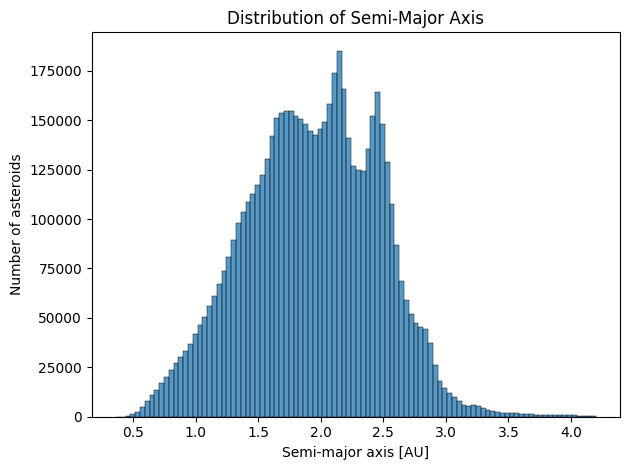

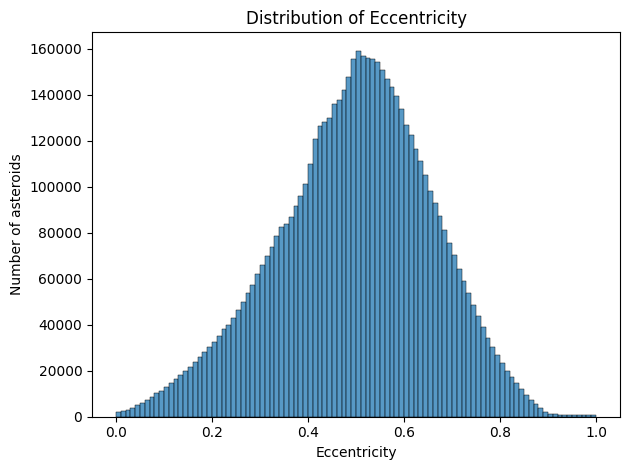

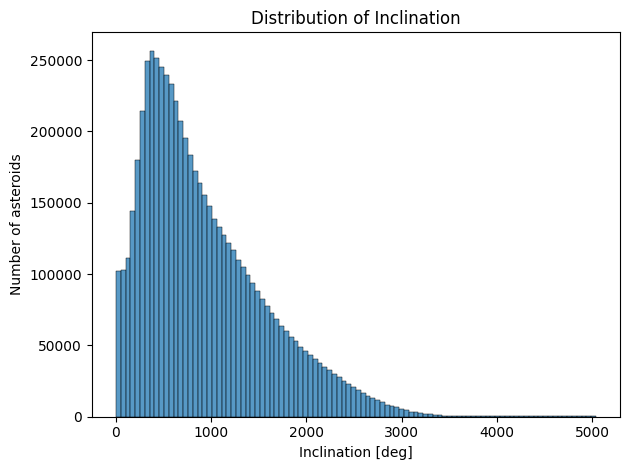

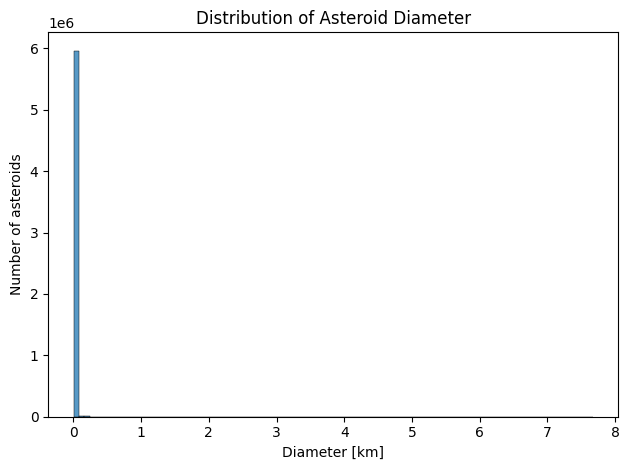

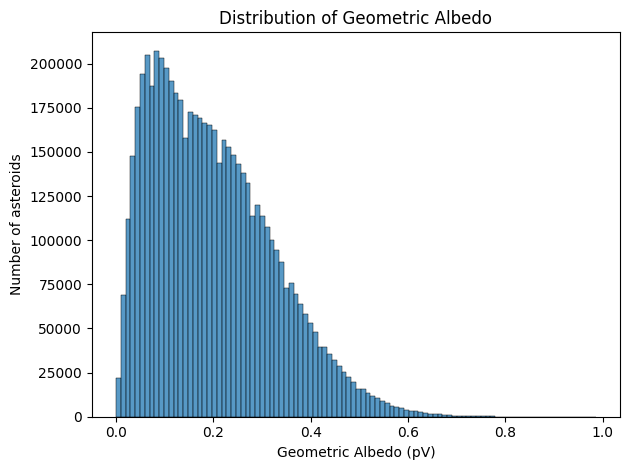

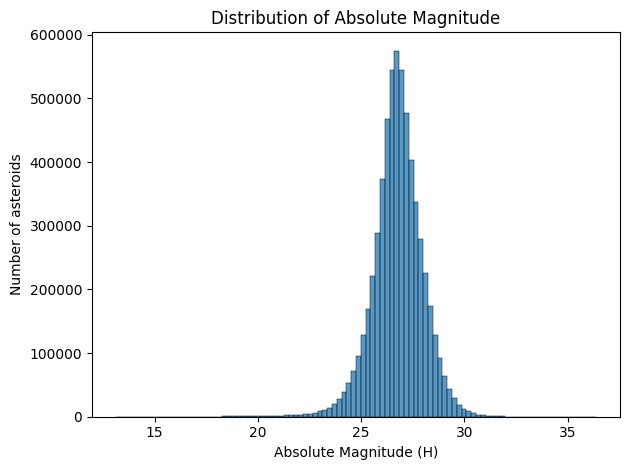

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load and convert all data types safely
columns = ["hmag", "a", "e", "i", "Diameter", "pV", "rp", "ra"]
df = pd.read_csv("Asteroids_6M_1.txt", delim_whitespace=True, names=columns, dtype=str)
df = df.apply(pd.to_numeric, errors='coerce')  # force all to float, NaNs if broken
df = df.dropna()

# Convert inclination to degrees
df["i_deg"] = df["i"] * (90 / max(df["i"]))

# Plot 1: Semi-major axis
plt.figure()
sns.histplot(df["a"], bins=100, color="tab:blue")
plt.xlabel("Semi-major axis [AU]")
plt.ylabel("Number of asteroids")
plt.title("Distribution of Semi-Major Axis")
plt.tight_layout()
plt.savefig("semi_major_axis_1.pdf")

# Plot 2: Eccentricity
plt.figure()
sns.histplot(df["e"], bins=100, color="tab:orange")
plt.xlabel("Eccentricity")
plt.ylabel("Number of asteroids")
plt.title("Distribution of Eccentricity")
plt.tight_layout()
plt.savefig("eccentricity_1.pdf")

# Plot 3: Inclination (deg)
plt.figure()
sns.histplot(df["i_deg"], bins=100, color="tab:green")
plt.xlabel("Inclination [deg]")
plt.ylabel("Number of asteroids")
plt.title("Distribution of Inclination")
plt.tight_layout()
plt.savefig("inclination_1.pdf")

# Plot 4: Diameter (log-log)
plt.figure()
log_bins = np.logspace(np.log10(df["Diameter"].min()), np.log10(df["Diameter"].max()), 100)
plt.hist(df["Diameter"], bins=log_bins, color="tab:red")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Diameter [km] (log scale)")
plt.ylabel("Number of asteroids (log scale)")
plt.title("Log-Log Distribution of Asteroid Diameter")
plt.tight_layout()
plt.savefig("diameter_loglog_1.pdf")

# Plot 5: Albedo
plt.figure()
sns.histplot(df["pV"], bins=100, color="tab:purple")
plt.xlabel("Geometric Albedo (pV)")
plt.ylabel("Number of asteroids")
plt.title("Distribution of Geometric Albedo")
plt.tight_layout()
plt.savefig("albedo_1.pdf")

# Plot 6: Absolute Magnitude
plt.figure()
sns.histplot(df["hmag"], bins=100, color="tab:brown")
plt.xlabel("Absolute Magnitude (H)")
plt.ylabel("Number of asteroids")
plt.title("Distribution of Absolute Magnitude")
plt.tight_layout()
plt.savefig("hmag_1.pdf")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Replace these with your actual file paths
files = {
    "Sim1": "Asteroids_6M_ID_1.txt",
    "Sim2": "Asteroids_6M_ID_2.txt",
    "Sim3": "Asteroids_6M_ID_3.txt"
}

columns = ["ID", "MOID", "a", "e", "i", "Omega", "omega", "theta0", "Diameter"]

# Load data
dfs = {}
for label, path in files.items():
    df = pd.read_csv(path, delim_whitespace=True, names=columns)
    df = df.apply(pd.to_numeric, errors='coerce')  # Ensure all numeric
    dfs[label] = df.dropna(subset=["MOID", "a", "e", "i", "Omega", "omega", "theta0"])

# Summary table
summary = pd.DataFrame({
    "Simulation": list(dfs.keys()),
    "Asteroid Count": [len(df) for df in dfs.values()]
})
print(summary.to_markdown(index=False))

def plot_param(dfs, param, xlabel, filename, bins=100, deg=False):
    plt.figure()
    for label, df in dfs.items():
        # Drop NaNs and convert to numeric safely
        values = pd.to_numeric(df[param], errors='coerce').dropna()
        if deg:
            values *= (180 / np.pi)
        values = values.astype(float)
        sns.histplot(values, label=label, bins=bins, stat="density", element="step", fill=False)
    plt.xlabel(xlabel)
    plt.ylabel("Normalized Density")
    plt.title(f"Distribution of {xlabel}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{filename}.pdf")
    plt.close()

# Generate all plots
plot_param(dfs, "MOID", "MOID [LD]", "moid", bins=100)
plot_param(dfs, "a", "Semi-major axis [AU]", "a", bins=100)
plot_param(dfs, "e", "Eccentricity", "e", bins=100)
plot_param(dfs, "i", "Inclination [deg]", "i", bins=100, deg=True)
plot_param(dfs, "Omega", "RAAN [deg]", "raan", bins=90, deg=True)
plot_param(dfs, "omega", "Argument of Periapsis [deg]", "argperi", bins=90, deg=True)
plot_param(dfs, "theta0", "True Anomaly [deg]", "trueanomaly", bins=90, deg=True)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Simulation input files
files = {
    "Sim1": "Asteroids_6M_App_1.txt",
    "Sim2": "Asteroids_6M_App_2.txt",
    "Sim3": "Asteroids_6M_App_3.txt"
}

# Column names
cols = ["ID", "DDi", "MMi", "YYYYi", "disti", "DDc", "MMc", "YYYYc",
        "distc", "velc", "Diameter", "DDo", "MMo", "YYYYo", "disto"]

dfs = {}

for sim, path in files.items():
    df = pd.read_csv(path, delim_whitespace=True, names=cols, comment="#", skiprows=1)
    
    # Convert to integers to ensure valid date construction
    df["DDi"] = pd.to_numeric(df["DDi"], errors="coerce").astype("Int64")
    df["MMi"] = pd.to_numeric(df["MMi"], errors="coerce").astype("Int64")
    df["YYYYi"] = pd.to_numeric(df["YYYYi"], errors="coerce").astype("Int64")

    df["DDc"] = pd.to_numeric(df["DDc"], errors="coerce").astype("Int64")
    df["MMc"] = pd.to_numeric(df["MMc"], errors="coerce").astype("Int64")
    df["YYYYc"] = pd.to_numeric(df["YYYYc"], errors="coerce").astype("Int64")

    df["DDo"] = pd.to_numeric(df["DDo"], errors="coerce").astype("Int64")
    df["MMo"] = pd.to_numeric(df["MMo"], errors="coerce").astype("Int64")
    df["YYYYo"] = pd.to_numeric(df["YYYYo"], errors="coerce").astype("Int64")
    
    # Build datetime fields
    df["date_in"] = pd.to_datetime(dict(year=df["YYYYi"], month=df["MMi"], day=df["DDi"]), errors="coerce")
    df["date_closest"] = pd.to_datetime(dict(year=df["YYYYc"], month=df["MMc"], day=df["DDc"]), errors="coerce")
    df["date_out"] = pd.to_datetime(dict(year=df["YYYYo"], month=df["MMo"], day=df["DDo"]), errors="coerce")

    df["duration_days"] = (df["date_out"] - df["date_in"]).dt.total_seconds() / (24 * 3600)
    
    dfs[sim] = df.dropna(subset=["date_in", "date_closest", "date_out"])


# Generalized plotting function
def comparative_plot(parameter, xlabel, filename, bins=100):
    plt.figure()
    for sim, df in dfs.items():
        sns.histplot(df[parameter], bins=bins, stat="density", element="step", fill=False, label=sim)
    plt.xlabel(xlabel)
    plt.ylabel("Normalized Density")
    plt.title(f"Distribution of {xlabel}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{filename}.pdf")
    plt.close()

# Plot physical and geometric quantities
comparative_plot("distc", "Closest Approach Distance [LD]", "closest_approach_distance")
comparative_plot("velc", "Flyby Velocity at Closest Approach [km/s]", "flyby_velocity")
comparative_plot("duration_days", "Encounter Duration [days]", "soi_encounter_duration")

# Plot: Asteroid diameter (log-log scale)
plt.figure()
for sim, df in dfs.items():
    sns.histplot(df["Diameter"], bins=100, stat="density", element="step", fill=False, label=sim)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Asteroid Diameter [m] (log scale)")
plt.ylabel("Normalized Density (log scale)")
plt.title("Distribution of Asteroid Diameters in SOI Encounters (Log-Log)")
plt.legend()
plt.tight_layout()
plt.savefig("soi_diameter_loglog.pdf")
plt.close()

# Plot event dates
for date_col, label in zip(["date_in", "date_closest", "date_out"],
                           ["Entry", "Closest Approach", "Exit"]):
    plt.figure()
    for sim, df in dfs.items():
        sns.histplot(df[date_col], bins=200, element="step", fill=False, label=sim)
    plt.xlabel(f"{label} Date")
    plt.ylabel("Number of Events")
    plt.title(f"{label} Date Distribution")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{label.lower().replace(' ', '_')}_dates.pdf")
    plt.close()

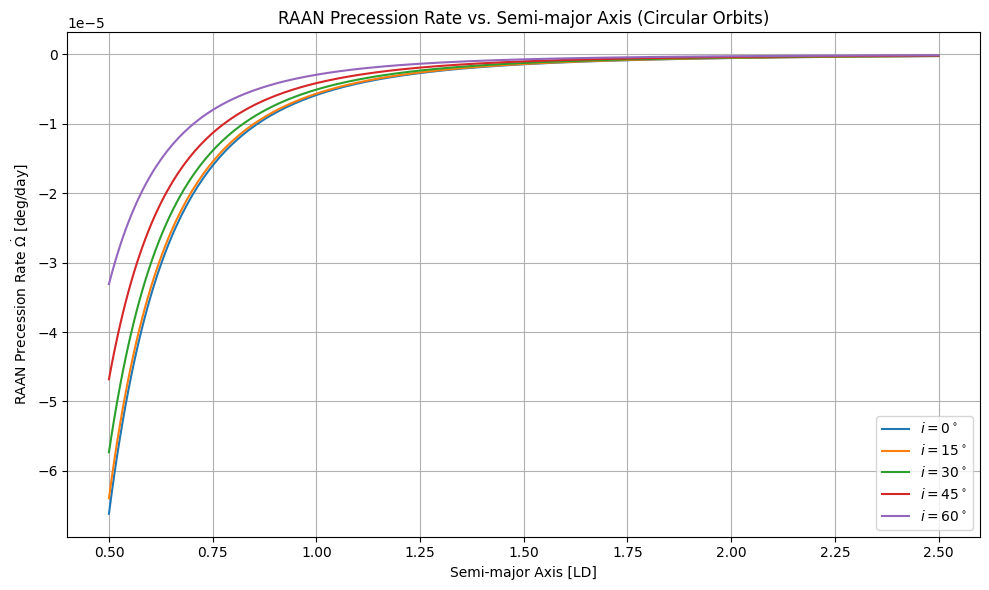

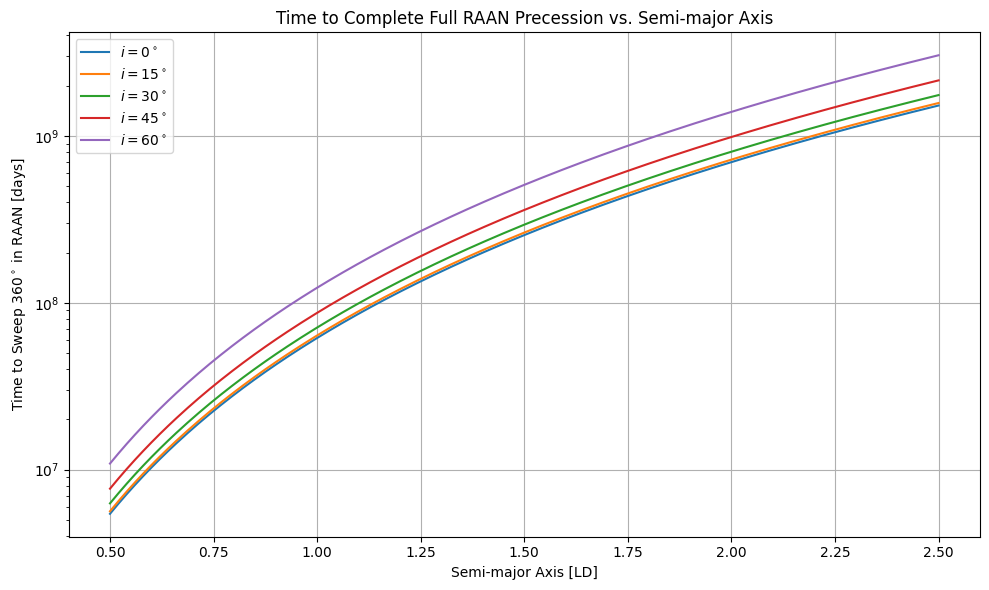

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
mu_E = 3.986e5         # [km^3/s^2] Earth's gravitational parameter
R_E = 6371             # [km] Earth's radius
J2 = 1.08263e-3        # Earth's J2 coefficient

# Lunar distance
LD = 384400  # [km]

# Sweep of semi-major axis values
a_values = np.linspace(0.5 * LD, 2.5 * LD, 300)  # [km]

# Circular orbit
e = 0

# Inclinations to evaluate [degrees]
inclinations_deg = [0, 15, 30, 45, 60]
inclinations_rad = np.radians(inclinations_deg)

# Mean motion [rad/s]
n = np.sqrt(mu_E / a_values**3)

# Dictionary to store RAAN rates
Omega_dot = {}

# Compute RAAN precession rate for each inclination
for i_rad, i_deg in zip(inclinations_rad, inclinations_deg):
    Omega_dot[i_deg] = -1.5 * J2 * (R_E / a_values)**2 * n * np.cos(i_rad) / (1 - e**2)**2
    Omega_dot[i_deg] = Omega_dot[i_deg] * (180 / np.pi) * 86400  # convert to deg/day

# Plot RAAN precession rate
plt.figure(figsize=(10, 6))
for i_deg in inclinations_deg:
    plt.plot(a_values / LD, Omega_dot[i_deg], label=f'$i = {i_deg}^\\circ$')

plt.xlabel('Semi-major Axis [LD]')
plt.ylabel('RAAN Precession Rate $\\dot{\\Omega}$ [deg/day]')
plt.title('RAAN Precession Rate vs. Semi-major Axis (Circular Orbits)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("raan_precession_rate.pdf")  # Export to PDF
plt.show()

# Plot time to complete 360° RAAN sweep
plt.figure(figsize=(10, 6))
for i_deg in inclinations_deg:
    sweep_time_days = 360 / np.abs(Omega_dot[i_deg])
    plt.semilogy(a_values / LD, sweep_time_days, label=f'$i = {i_deg}^\\circ$')

plt.xlabel('Semi-major Axis [LD]')
plt.ylabel('Time to Sweep 360$^\\circ$ in RAAN [days]')
plt.title('Time to Complete Full RAAN Precession vs. Semi-major Axis')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("raan_precession_sweep_time.pdf")  # Export to PDF
plt.show()


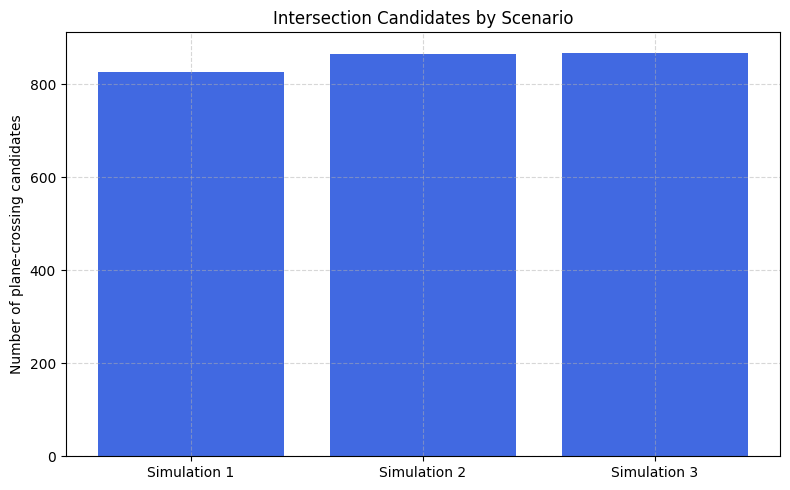

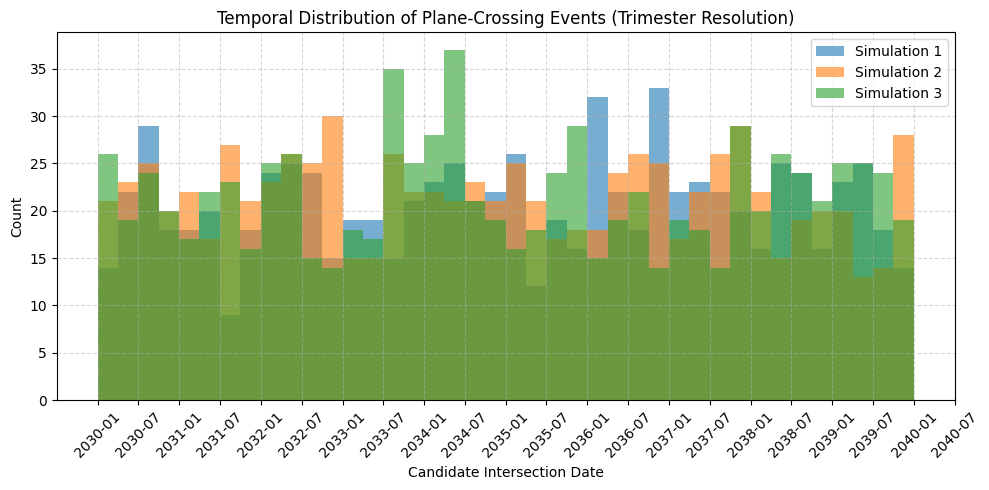

In [1]:
! pip install lamberthub
import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from lamberthub import gooding1990
import os

# Physical constants and planetary parameters
AU_TO_M = 1.496e11               # Astronomical unit [m]
LD_TO_M = 4e8                    # Lunar distance [m]
MU_SUN = 1.327e20                # Gravitational parameter of the Sun [m^3/s^2]
MU_EARTH = 3.986e14              # Gravitational parameter of the Earth [m^3/s^2]

# Earth's orbital elements (J2000)
ae = 1.00000011 * AU_TO_M        # Semi-major axis [m]
ee = 0.01671022                  # Eccentricity
deg = np.pi / 180                # Degrees to radians conversion
ie = 0.00005 * deg               # Inclination [rad]
Omegae = -11.26064 * deg         # RAAN [rad]
omegae = 102.94719 * deg         # Argument of periapsis [rad]
theta0e = 300 * deg              # True anomaly [rad]

# Thruster and maneuver parameters
g0 = 9.81                        # Standard gravity [m/s^2]
DVTlim = 250                     # Delta-V limit per asteroid [m/s]
orbdist = LD_TO_M                # Nominal orbital distance [m]

# Time settings
t0 = datetime(2030, 1, 1)        # Start date
tf = datetime(2040, 1, 1)        # End date

# Flyby geometry and sampling
npoints = 1000                  # Number of points per flyby
theta0 = 30                     # Initial camera angle [deg]

# Fundamental physics
c = 3e8                         # Speed of light [m/s]
freq = 32e9                     # Frequency [Hz]
waveL = c / freq                # Wavelength [m]
um = 1e-6                       # Micrometer [m]
hplanck = 6.626e-34             # Planck constant [J*s]
kb = 1.380649e-23               # Boltzmann constant [J/K]

# Earth physical parameters
Rearth = 6.371e6                # Earth's radius [m]
J2earth = 1.08264e-3            # J2 perturbation coefficient
Psidereal = 86400               # Sidereal day [s]

# Ground station location and visibility
lambdaGS, thetaGS = 0, 0        # Longitude and latitude [rad]
limitangle = 5                  # Min elevation angle [deg]

# Communication system settings
dB_transmitGain = 20            # Spacecraft transmit antenna gain [dB]
transmitPower = 15              # Transmit power [W]
dataRate = 3000                 # Desired data rate [bps]
EoverN = 10                     # Required Eb/N0 (linear)
Ts = 150                        # System noise temperature [K]
GGS = 45                        # Ground station gain [dB]

# Time resolution for simulation
step_hours = 1
max_hours = 87660               # Maximum simulated hours (~10 years)

# Power values
P_dict = {
    'idle': 100,          # W
    'propulsion': 800,    # W
    'observation': 300,   # W
    'panel_op': 150       # W
}

def true_anomaly_through_radius(a, e, r):
    """
    Calculates the true anomaly (θ) at a given orbital radius (r) for an orbit
    defined by its semi-major axis (a) and eccentricity (e).
    Parameters:
    a : float
        Semi-major axis of the orbit [units: distance, e.g., km or AU]
    e : float
        Orbital eccentricity (0 = circular, 0 < e < 1 = elliptical)
    r : float
        Orbital radius at which to calculate the true anomaly [same units as a]
    Returns:
    theta : float
        True anomaly in radians. The angle between the direction of periapsis
        and the current position of the body, as seen from the central focus.
    """
    # Using the orbit geometry equation to solve for the true anomaly
    theta = np.arccos((1/e)*(a*(1-e**2)/r-1))
    return theta

def modify_date_by_offset(closest_approach_date, time_offset):
    """
    Modifies a given datetime by adding or subtracting a time offset in seconds.
    Parameters:
    closest_approach_date : datetime.datetime
        The original date and time (e.g., of a closest approach or event).
    time_offset : float or int
        Time offset in seconds. Can be positive (future) or negative (past).
    Returns:
    datetime.datetime
        A new datetime object offset by the specified number of seconds.
    """
    return closest_approach_date + timedelta(seconds=time_offset)

def eccentric_anomaly(e, M, delta=1e-6):
    """
    Solves Kepler's Equation for the eccentric anomaly (E) given the
    orbital eccentricity and the mean anomaly using the Newton-Raphson method.
    Kepler's Equation: M = E - e * sin(E)
    Parameters:
    e : float
        Orbital eccentricity (0 ≤ e < 1 for elliptical orbits)
    M : float
        Mean anomaly in radians (angle from 0 to 2π)
    delta : float, optional
        Convergence tolerance for the Newton-Raphson iteration (default: 1e-6)
    Returns:
    E : float
        Eccentric anomaly in radians. The solution to Kepler's Equation.
    """
    E = M  # Initial guess: E ≈ M for small eccentricities
    error = delta + 1  # Ensure the loop runs at least once
    while error > delta:
        # Kepler's Equation: f(E) = E - e*sin(E) - M
        f = E-e*np.sin(E)-M
        f_prime = 1-e*np.cos(E)  # Derivative of f(E) with respect to E
        # Newton-Raphson iteration
        E_new = E - f/f_prime
        error = abs(E_new-E)
        if error < delta:
            return E_new  # Return early if converged
        E = E_new  # Update estimate
    return E  # Return last estimate (should be within delta of actual)

def theta_evolution(a, e, theta0, dt, mu):
    """
    Computes the future true anomaly (theta) of a body in an elliptical orbit
    after a time interval dt has elapsed, using Keplerian orbital mechanics.
    Parameters:
    a : float
        Semi-major axis of the orbit [units: distance, e.g., meters or km]
    e : float
        Orbital eccentricity (0 < e < 1 for elliptical orbits)
    theta0 : float
        Initial true anomaly [radians]
    dt : float
        Time elapsed since theta0 [seconds]
    mu : float
        Standard gravitational parameter (G*M) of the central body [m^3/s^2]
    Returns:
    theta : float
        New true anomaly after time dt [radians]
    """
    # 1. Compute the orbital period (P) using Kepler's third law
    P = 2 * np.pi * np.sqrt(a**3 / mu)
    # 2. Convert initial true anomaly to eccentric anomaly (E0)
    E0 = np.arctan2(np.sqrt(1 - e**2) * np.sin(theta0), e + np.cos(theta0))
    # 3. Compute initial mean anomaly (M0) from eccentric anomaly
    M0 = E0 - e * np.sin(E0)
    # 4. Advance mean anomaly by dt seconds
    M = M0 + 2 * np.pi * dt / P  # Mean anomaly increases linearly with time
    # 5. Solve Kepler's Equation to find updated eccentric anomaly (E)
    E = eccentric_anomaly(e, M)
    # 6. Convert eccentric anomaly back to true anomaly (theta)
    theta = np.arctan2(np.sqrt(1 - e**2) * np.sin(E), np.cos(E) - e)
    return theta

def orbelem(rvec, vvec, mu):
    """
    Computes the classical orbital elements from position and velocity vectors
    in an inertial reference frame.
    Parameters:
    rvec : array_like
        Position vector [m] of the orbiting body with respect to the central body (3D)
    vvec : array_like
        Velocity vector [m/s] of the orbiting body (3D)
    mu : float
        Standard gravitational parameter of the central body (G*M) [m^3/s^2]
    Returns:
    a : float
        Semi-major axis [m]
    e : float
        Eccentricity (dimensionless)
    i : float
        Inclination [rad]
    Omega : float
        Longitude of the ascending node [rad]
    omega : float
        Argument of periapsis [rad]
    theta : float
        True anomaly [rad]
    lvec : ndarray
        Specific angular momentum vector [m^2/s]
    """
    # Specific angular momentum vector (h = r × v)
    lvec = np.cross(rvec, vvec)  # [m^2/s]
    # Norms
    r = np.linalg.norm(rvec)       # Distance [m]
    v = np.linalg.norm(vvec)       # Speed [m/s]
    l = np.linalg.norm(lvec)       # |h| [m^2/s]
    # Eccentricity vector
    evec = np.cross(vvec, lvec) / mu - rvec / r  # dimensionless
    e = np.linalg.norm(evec)
    # Semi-major axis from vis-viva / orbital energy relation
    a = (l**2 / mu) / (1 - e**2)
    # Inclination (i): angle between h and z-axis
    i = np.arccos(lvec[2] / l)
    # Node vector: pointing toward ascending node
    N = np.cross([0, 0, 1], lvec)
    N_norm = np.linalg.norm(N)
    # Longitude of the ascending node (Ω)
    if N[1] >= 0:
        Omega = np.arccos(N[0] / N_norm)
    else:
        Omega = 2 * np.pi - np.arccos(N[0] / N_norm)
    # Argument of periapsis (ω): angle from node to periapsis in orbital plane
    if evec[2] >= 0:
        omega = np.arccos(np.dot(N / N_norm, evec / e))
    else:
        omega = 2 * np.pi - np.arccos(np.dot(N / N_norm, evec / e))
    # Radial velocity component to determine direction of motion
    vr = np.dot(rvec, vvec) / r
    # True anomaly (θ): angle from periapsis to current position
    if vr >= 0:
        theta = np.arccos(np.dot(evec / e, rvec / r))
    else:
        theta = 2 * np.pi - np.arccos(np.dot(evec / e, rvec / r))
    return a, e, i, Omega, omega, theta, lvec

def orbital_elements_to_state_vectors(a, e, i, Omega, omega, nu_array, mu):
    """
    Converts Keplerian orbital elements into position and velocity vectors
    in an inertial frame, for a given set of true anomalies.
    Parameters:
    a : float
        Semi-major axis [m]
    e : float
        Eccentricity (dimensionless)
    i : float
        Inclination [rad]
    Omega : float
        Longitude of the ascending node (Ω) [rad]
    omega : float
        Argument of periapsis (ω) [rad]
    nu_array : float or array_like
        True anomaly or array of true anomalies [rad]
    mu : float
        Standard gravitational parameter of the central body [m^3/s^2]
    Returns:
    r_vectors : ndarray
        Array of position vectors in the inertial frame [m], shape (n, 3)
    v_vectors : ndarray
        Array of velocity vectors in the inertial frame [m/s], shape (n, 3)
    """
    # Ensure input is treated as a NumPy array
    nu_array = np.asarray(nu_array)
    # Semi-latus rectum (p = a(1 - e^2))
    p = a * (1 - e**2)
    # Radius at each true anomaly (r = p / (1 + e cos(ν)))
    r_array = p / (1 + e * np.cos(nu_array))
    # Position vector in perifocal (PQW) frame
    r_pqw = np.column_stack((
        r_array * np.cos(nu_array),  # x_PQW
        r_array * np.sin(nu_array),  # y_PQW
        np.zeros_like(nu_array)      # z_PQW = 0 (orbital plane)
    ))
    # Velocity vector in perifocal frame
    sqrt_mu_p = np.sqrt(mu / p)
    v_pqw = np.column_stack((
        -sqrt_mu_p * np.sin(nu_array),                  # vx_PQW
        sqrt_mu_p * (e + np.cos(nu_array)),             # vy_PQW
        np.zeros_like(nu_array)                         # vz_PQW = 0
    ))
    # Compute cos/sin values for rotation matrix components
    cos_Omega, sin_Omega = np.cos(Omega), np.sin(Omega)
    cos_i, sin_i = np.cos(i), np.sin(i)
    cos_omega, sin_omega = np.cos(omega), np.sin(omega)
    # Rotation matrix from PQW to inertial frame (3-1-3 Euler rotation)
    rotation_matrix = np.array([
        [cos_Omega * cos_omega - sin_Omega * sin_omega * cos_i,
         -cos_Omega * sin_omega - sin_Omega * cos_omega * cos_i,
         sin_Omega * sin_i],
        [sin_Omega * cos_omega + cos_Omega * sin_omega * cos_i,
         -sin_Omega * sin_omega + cos_Omega * cos_omega * cos_i,
         -cos_Omega * sin_i],
        [sin_omega * sin_i,
         cos_omega * sin_i,
         cos_i]])
    # Apply rotation to transform PQW vectors to inertial frame
    r_vectors = np.dot(r_pqw, rotation_matrix.T)
    v_vectors = np.dot(v_pqw, rotation_matrix.T)
    return r_vectors, v_vectors

def time_evolution(a, e, i, Omega, omega, theta0, dt, mu):
    """
    Propagates an orbit defined by classical orbital elements forward in time by dt seconds,
    and returns the resulting position and velocity in the inertial frame.
    Parameters:
    a : float
        Semi-major axis [m]
    e : float
        Orbital eccentricity (0 < e < 1 for elliptical orbits)
    i : float
        Inclination [rad]
    Omega : float
        Longitude of the ascending node [rad]
    omega : float
        Argument of periapsis [rad]
    theta0 : float
        Initial true anomaly [rad]
    dt : float
        Time elapsed from initial position [s]
    mu : float
        Gravitational parameter of the central body [m^3/s^2]
    Returns:
    r_ijk[0] : float
        X-position in inertial frame [m]
    r_ijk[1] : float
        Y-position in inertial frame [m]
    r_ijk[2] : float
        Z-position in inertial frame [m]
    v_ijk[0] : float
        X-velocity in inertial frame [m/s]
    v_ijk[1] : float
        Y-velocity in inertial frame [m/s]
    v_ijk[2] : float
        Z-velocity in inertial frame [m/s]
    """
    # 1. Compute orbital period using Kepler's third law
    P = 2 * np.pi * np.sqrt(a**3 / mu)
    # 2. Convert initial true anomaly to eccentric anomaly
    E0 = np.arctan2(np.sqrt(1 - e**2) * np.sin(theta0), e + np.cos(theta0))
    # 3. Compute initial mean anomaly
    M0 = E0 - e * np.sin(E0)
    # 4. Advance mean anomaly by dt seconds
    M = M0 + 2 * np.pi * dt / P
    # 5. Solve Kepler's equation to find new eccentric anomaly
    E = eccentric_anomaly(e, M)
    # 6. Convert eccentric anomaly to true anomaly
    theta = np.arctan2(np.sqrt(1 - e**2) * np.sin(E), np.cos(E) - e)
    # 7. Compute orbital radius at new true anomaly
    r = a * (1 - e**2) / (1 + e * np.cos(theta))
    # 8. Approximate orbital speed (only valid for small eccentricity or circular orbits)
    v = np.sqrt(mu / a)
    # 9. Position in perifocal (PQW) frame
    r_pqw = np.array([r * np.cos(theta), r * np.sin(theta), 0])
    # 10. Velocity in perifocal (PQW) frame (approximation)
    v_pqw = np.array([-v * np.sin(theta),v * (e + np.cos(theta)),0])
    # 11. Construct 3-1-3 rotation matrix from perifocal to inertial (IJK) frame
    R1 = np.array([
        [np.cos(Omega), -np.sin(Omega), 0],
        [np.sin(Omega),  np.cos(Omega), 0],
        [0,              0,             1]
    ])
    R2 = np.array([
        [1, 0,          0         ],
        [0, np.cos(i), -np.sin(i)],
        [0, np.sin(i),  np.cos(i)]
    ])
    R3 = np.array([
        [np.cos(omega), -np.sin(omega), 0],
        [np.sin(omega),  np.cos(omega), 0],
        [0,              0,             1]
    ])
    R = R1 @ R2 @ R3  # Combined rotation matrix
    # 12. Transform vectors to inertial frame
    r_ijk = R @ r_pqw
    v_ijk = R @ v_pqw
    return r_ijk[0], r_ijk[1], r_ijk[2], v_ijk[0], v_ijk[1], v_ijk[2]

def time_since_periapsis_hyperbolic(theta, a, e, mu):
    """
    Computes the time elapsed since periapsis for a hyperbolic trajectory
    given the true anomaly.
    Parameters:
    theta : float
        True anomaly [rad] (θ ≠ 0). Positive before and after periapsis.
    a : float
        Semi-major axis [m] (must be negative for hyperbolic orbits)
    e : float
        Eccentricity (must be > 1 for hyperbolic trajectories)
    mu : float
        Gravitational parameter [m^3/s^2]
    Returns:
    t : float
        Time since periapsis passage [s]. Negative for pre-periapsis points.
    """
    if e <= 1 or a >= 0:
        raise ValueError("Invalid parameters: hyperbolic orbits require e > 1 and a < 0.")
    # 1. Compute the hyperbolic anomaly H from the true anomaly θ
    sinh_H = (e + np.cos(theta)) / np.sqrt(e**2 - 1)
    H = np.arcsinh(sinh_H)
    # 2. Mean motion for hyperbolic trajectory
    n = np.sqrt(mu / abs(a)**3)
    # 3. Time since periapsis passage
    t = (e * np.sinh(H) - H) / n
    # 4. Assign negative time to negative true anomalies
    if theta < 2*np.pi and theta > np.pi:
        t *= -1
    return t

def time_since_periapsis_hyperbolic_array(theta, a, e, mu):
    """
    Computes time since periapsis for an array of true anomalies in a hyperbolic orbit.
    Parameters:
    theta : array_like
        True anomalies [rad]. Can be scalar or 1D array. Negative θ means pre-periapsis.
    a : float
        Semi-major axis [m] (must be negative for hyperbolic orbits)
    e : float
        Eccentricity (must be > 1 for hyperbolic trajectories)
    mu : float
        Gravitational parameter [m^3/s^2]
    Returns:
    t : ndarray
        Time since periapsis [s], same shape as input theta.
        Negative values indicate time before periapsis.
    """
    if e <= 1 or a >= 0:
        raise ValueError("Invalid parameters: hyperbolic orbits require e > 1 and a < 0.")
    # 1. Ensure theta is a NumPy array for vectorized computation
    theta = np.asarray(theta)
    # 2. Compute hyperbolic anomaly H from true anomaly θ:
    sinh_H = (e + np.cos(theta)) / np.sqrt(e**2 - 1)
    H = np.arcsinh(sinh_H)
    # 3. Mean motion for hyperbolic trajectory
    n = np.sqrt(mu / abs(a)**3)
    # 4. Time since periapsis
    t = (e * np.sinh(H) - H) / n
    # 5. Assign negative time to negative true anomalies
    t[theta < 0] *= -1
    return t

def find_closest_z_crossing_state(r_vectors, v_vectors, time_vector, target_radius):
    """
    Identifies the state (position, velocity, time) at the z=0 crossing
    that occurs at a radius closest to a specified target value.
    Parameters:
    r_vectors : ndarray, shape (N, 3)
        Array of position vectors [m] over time.
    v_vectors : ndarray, shape (N, 3)
        Array of velocity vectors [m/s] corresponding to r_vectors.
    time_vector : ndarray, shape (N,)
        Array of time values [s] associated with r_vectors/v_vectors.
    target_radius : float
        Target radius [m] at which the z-crossing is most relevant (e.g. periapsis plane).
    Returns:
    t_cross : float
        Interpolated time [s] of the closest z=0 crossing.
    r_cross : ndarray, shape (3,)
        Interpolated position vector [m] at the crossing.
    v_cross : ndarray, shape (3,)
        Interpolated velocity vector [m/s] at the crossing.
    Returns None if no z-crossing is detected.
    """
    z_values = r_vectors[:, 2]  # Extract the z-coordinates
    crossing_data = []  # Store tuples of (t_cross, r_cross, v_cross, r_magnitude)
    # Iterate through consecutive points to find z-crossings
    for i in range(len(z_values) - 1):
        z1, z2 = z_values[i], z_values[i + 1]
        t1, t2 = time_vector[i], time_vector[i + 1]
        r1, r2 = r_vectors[i], r_vectors[i + 1]  # Position vectors
        v1, v2 = v_vectors[i], v_vectors[i + 1]  # Velocity vectors
        r1_mag, r2_mag = np.linalg.norm(r1), np.linalg.norm(r2)  # Compute radii
        # Check for sign change (crossing)
        if z1 * z2 < 0:  # One is positive, one is negative
            # Linear interpolation factor
            alpha = (0 - z1) / (z2 - z1)
            # Interpolated time
            t_cross = t1 + alpha * (t2 - t1)
            # Interpolated position and velocity vectors
            r_cross = r1 + alpha * (r2 - r1)
            v_cross = v1 + alpha * (v2 - v1)
            # Interpolated radius
            r_cross_mag = np.linalg.norm(r_cross)
            # Store crossing data
            crossing_data.append((t_cross, r_cross, v_cross, r_cross_mag))
    if not crossing_data:
        return None  # No crossing found
    # Find the crossing with radius closest to the target
    closest_crossing = min(crossing_data, key=lambda x: abs(x[3] - target_radius))
    # Extract results
    t_cross, r_cross, v_cross, _ = closest_crossing
    return t_cross, r_cross, v_cross

def compute_transfer_time_and_delta_v(v_initial, mu, r_asteroid, r_orbit):
    """
    Computes transfer orbit properties between an asteroid's position and
    a target circular orbit, including the required delta-v and time of flight.
    Parameters:
    v_initial : float
        Initial spacecraft speed [m/s] at the asteroid's location.
    mu : float
        Standard gravitational parameter of the central body [m^3/s^2].
    r_asteroid : ndarray, shape (3,)
        Position vector of the asteroid [m].
    r_orbit : float
        Radius of the final circular orbit (assumed centered at the origin) [m].
    Returns:
    r_opposed : ndarray, shape (3,)
        Position vector of the target location (opposite direction from asteroid, same radius as target orbit) [m].
    v_opposed : ndarray, shape (3,)
        Direction vector for transfer arrival velocity (normalized and scaled to v_initial) [m/s].
    transfer_time : float
        Time of flight for the transfer [s].
    delta_v : float
        Required delta-v for the maneuver [m/s].
    a : float
        Semi-major axis of the transfer orbit [m].
    e : float
        Eccentricity of the transfer orbit (dimensionless).
    """
    # Compute the opposed position vector
    r_opposed = -r_asteroid*r_orbit/np.linalg.norm(r_asteroid)
    v_opposed = v_initial*np.array([-r_opposed[1],r_opposed[0],0])/np.linalg.norm(r_opposed);
    # Compute magnitudes of the position vectors
    r1 = np.linalg.norm(r_asteroid)
    r2 = np.linalg.norm(r_opposed)
    # Compute the semi-major axis of the transfer orbit
    a = (r1 + r2) / 2
    if r1 < r2:
        e = 1 - r1/a
    elif r1 > r2:
        e = 1 - r2/a
    else:
        e = 0
    # Compute the velocity at the initial position in the transfer orbit using vis-viva
    v_transfer = np.sqrt(mu * (2 / r2 - 1 / a))
    v_sc = np.sqrt(mu * (2 / r1 - 1 / a))
    # Compute the required delta-v
    delta_v = abs(v_transfer - v_initial)
    # Compute the transfer time (half of the full orbital period)
    transfer_time = np.pi * np.sqrt(a**3 / mu)
    return r_opposed, v_opposed, transfer_time, delta_v, a, e

def compute_transfer_start_date_and_true_anomalies(r_orbit, initial_epoch, transfer_time, visit_date, mu):
    """
    Computes the date at which a transfer must start to reach a given visit date,
    and the corresponding true anomaly difference between the spacecraft and the target.
    Parameters:
    r_orbit : ndarray, shape (3,)
        Position vector of the circular target orbit at the transfer arrival time [m].
    initial_epoch : datetime.datetime
        Reference epoch of the spacecraft's orbital phase [UTC datetime].
    transfer_time : float
        Duration of the transfer (e.g., from Lambert solution) [s].
    visit_date : datetime.datetime
        Date/time at which the spacecraft must arrive at the target [UTC datetime].
    mu : float
        Gravitational parameter of the central body [m^3/s^2].
    Returns:
    Dtheta : float
        Angular difference in true anomaly [rad] between the spacecraft's location
        and the target orbit at transfer start (positive if spacecraft is ahead).
    transfer_start_date : datetime.datetime
        Date/time at which the transfer must start [UTC datetime].
    true_anomaly_transfer_start : float
        True anomaly of the target orbit at transfer start [rad].
    """
    # Compute the transfer start date
    transfer_start_date = visit_date - timedelta(seconds=transfer_time)
    # Compute the orbital radius (since the orbit is circular, this is just the magnitude of r_orbit)
    r = np.linalg.norm(r_orbit)
    # Compute the mean motion (rad/s)
    mean_motion = np.sqrt(mu / r**3)
    # Compute the elapsed time since the initial epoch to the transfer start date
    elapsed_time = (transfer_start_date - initial_epoch).total_seconds()
    # Compute the true anomaly at the transfer start date
    true_anomaly_transfer_start = np.arctan2(r_orbit[1],r_orbit[0])
    # Compute the true anomaly of the spacecraft evolved from the initial epoch
    true_anomaly_evolved = (mean_motion * elapsed_time) % (2 * np.pi)
    # Compute difference in true anomaly
    Dtheta = true_anomaly_evolved - true_anomaly_transfer_start
    if Dtheta > np.pi:
        Dtheta -= 2 * np.pi
    return Dtheta, transfer_start_date, true_anomaly_transfer_start

def compute_phase_dv(phase_difference, max_time, r_circular, mu):
    """
    Computes the delta-V and orbit parameters needed to perform a phasing maneuver
    that corrects a phase difference with a target on a circular orbit.
    Parameters:
    phase_difference : float
        Desired phase shift between spacecraft and target [rad]
        Positive if the target is behind (trailing), negative if ahead (leading)
    max_time : float
        Maximum time allowed to complete the phasing maneuver [s]
    r_circular : float
        Radius of the circular reference orbit [m]
    mu : float
        Gravitational parameter of the central body [m^3/s^2]
    Returns:
    total_dv : float
        Total delta-V [m/s] required for the phasing maneuver (two burns)
    delta_t : float
        Duration of the phasing maneuver [s]
    n_revs : int
        Number of full revolutions in the phasing orbit
    a_transfer : float
        Semi-major axis of the phasing orbit [m]
    e_transfer : float
        Eccentricity of the phasing orbit (dimensionless)
    Returns None if no phasing solution is possible within max_time.
    """
    # Compute mean motion of the initial orbit
    n = np.sqrt(mu / r_circular**3)
    # Compute the total angular displacement needed
    delta_theta = phase_difference
    # Compute required semi-major axis using the phasing equation
    n_revs = np.floor(max_time / (2 * np.pi / n))  # Maximum number of orbits allowed
    if n_revs == 0:
        return None
    else:
        delta_t = -delta_theta / n + (2 * np.pi * n_revs) / n  # Time for phasing
        a_transfer = (mu * (delta_t / (2 * np.pi * n_revs))**2)**(1/3)  # Semi-major axis of phasing orbit
        if a_transfer < r_circular:
            e_transfer = r_circular/a_transfer-1
        elif r_circular < a_transfer:
            e_transfer = 1-r_circular/a_transfer
        else:
            e_transfer = 0
        # Compute velocity changes using vis-viva equation
        v_circular = np.sqrt(mu / r_circular)
        v_transfer = np.sqrt(mu * (2 / r_circular - 1 / a_transfer))
        # Determine ΔV based on the sign of the phase difference
        if phase_difference > 0:
            # Target trails: Increase velocity at start, decrease at end
            dv_i = v_transfer - v_circular
            dv_f = -(v_transfer - v_circular)
        else:
            # Target leads: Decrease velocity at start, increase at end
            dv_i = -(v_transfer - v_circular)
            dv_f = v_transfer - v_circular
        total_dv = abs(dv_i) + abs(dv_f)
        return total_dv, delta_t, n_revs, a_transfer, e_transfer

def transfer_correction(a, r_opposed, v_opposed, r_asteroid, transfer_time, Isp, g0, mu, m):
    """
    Applies a phase correction to an interplanetary transfer to improve alignment
    with the target. Uses an approximate burn offset and solves the Lambert problem
    to compute corrected velocity and thrust requirements.
    Parameters:
    a : float
        Semi-major axis of the transfer orbit [m]
    r_opposed : ndarray, shape (3,)
        Original arrival position vector at the end of transfer [m]
    v_opposed : ndarray, shape (3,)
        Original arrival velocity vector [m/s]
    r_asteroid : ndarray, shape (3,)
        Target asteroid position vector at the time of arrival [m]
    transfer_time : float
        Time of flight for the transfer (initial estimate) [s]
    Isp : float
        Specific impulse of the propulsion system [s]
    g0 : float
        Standard gravity [m/s^2]
    mu : float
        Gravitational parameter of the central body [m^3/s^2]
    m : float
        Spacecraft initial mass [kg]
    Returns:
    thrust : float
        Required thrust [N] to execute the corrected maneuver
    phase_correction : float
        Time correction (in radians) applied to the phase [rad]
    delta_v : float
        Required delta-V for the corrected transfer [m/s]
    dt : float
        Corrected time of flight [s]
    v2_ : ndarray, shape (3,)
        Corrected arrival velocity vector at the target [m/s]
    """
    # Burn duration as 1/10th of the orbital period
    orbital_period = 2*np.pi*np.sqrt(a**3/mu)
    burn_duration = orbital_period / 10
    # Estimate phase correction in time
    mean_motion = 2 * np.pi / orbital_period  # Mean motion (rad/s)
    phase_correction = -(burn_duration / 2) * mean_motion  # Approximate phase shift in seconds
    Rz = np.array([
        [np.cos(phase_correction), -np.sin(phase_correction), 0],
        [np.sin(phase_correction),  np.cos(phase_correction), 0],
        [0,              0,             1]
    ])
    r1 = Rz @ r_opposed
    v1 = Rz @ v_opposed
    r2 = r_asteroid
    dt = transfer_time + burn_duration/2
    v1_, v2_ = gooding1990(mu, r1, r2, dt, 0, True)
    delta_v = np.linalg.norm(v1_-v1);
    # Calculate mass flow rate from the rocket equation
    exhaust_velocity = Isp * g0
    alpha = np.exp(delta_v/exhaust_velocity)
    mass_flow_rate = m*(alpha-1)/(alpha*burn_duration)
    # Calculate thrust (T = m_dot * Ve)
    thrust = mass_flow_rate * exhaust_velocity
    return thrust, phase_correction, delta_v, dt, v2_

def phase_correction(a, atrans, etrans, vorb, transfer_time, n_revs, Isp, g0, mu, m):
    """
    Applies a phase correction to a transfer maneuver by introducing a short-duration burn
    and computing the new required thrust using the rocket equation and Lambert solver.
    Parameters:
    a : float
        Radius of the circular orbit before the transfer [m]
    atrans : float
        Semi-major axis of the phasing/transfer orbit [m]
    etrans : float
        Eccentricity of the phasing orbit (dimensionless)
    vorb : float
        Velocity in the circular orbit before the transfer [m/s]
    transfer_time : float
        Duration of the planned transfer maneuver [s]
    n_revs : int
        Number of phasing revolutions (used to divide transfer time) [dimensionless]
    Isp : float
        Specific impulse of the engine [s]
    g0 : float
        Standard gravity [m/s^2]
    mu : float
        Gravitational parameter of the central body [m^3/s^2]
    m : float
        Initial spacecraft mass [kg]
    Returns:
    thrust : float
        Required thrust to achieve the corrected transfer [N]
    phase_correction : float
        Phase shift introduced due to burn delay [rad]
    delta_v : float
        Total delta-V required for the correction maneuver [m/s]
    dt_total : float
        Adjusted total duration of the maneuver [s]
    """
    # Burn duration as 1/20th of the orbital period
    orbital_period = 2*np.pi*np.sqrt(a**3/mu)
    burn_duration = orbital_period / 10
    # Estimate phase correction in time
    mean_motion = 2 * np.pi / orbital_period  # Mean motion (rad/s)
    phase_correction = -(burn_duration / 2) * mean_motion  # Approximate phase shift in seconds
    Rz = np.array([
        [np.cos(phase_correction), -np.sin(phase_correction), 0],
        [np.sin(phase_correction),  np.cos(phase_correction), 0],
        [0,              0,             1]
    ])
    r1 = Rz @ np.array([a, 0, 0])
    v1 = Rz @ np.array([0, vorb, 0])
    if atrans > a:
        r = -atrans*(1+etrans)
    else:
        r = -atrans*(1-etrans)
    r2 = np.array([r, 0, 0])
    dt = transfer_time/(2*n_revs) + burn_duration/2
    dttotal = transfer_time+burn_duration/2
    v1_, v2_ = gooding1990(mu, r1, r2, dt, 0, True)
    delta_v = 2*np.linalg.norm(v1_-v1);
    # Calculate mass flow rate from the rocket equation
    exhaust_velocity = Isp * g0
    alpha = np.exp(delta_v/2/exhaust_velocity)
    mass_flow_rate = m*(alpha-1)/(alpha*burn_duration)
    # Calculate thrust (T = m_dot * Ve)
    thrust = mass_flow_rate * exhaust_velocity
    return thrust, phase_correction, delta_v, dttotal

def fuel_mass_computation(m0, DVv, DVp, Isp, g0):
    """
    Computes the final spacecraft mass and total fuel consumed for a maneuver
    consisting of four burns: two velocity burns (DVv) and two position burns (DVp),
    assuming symmetric application and the rocket equation.
    Parameters:
    m0 : float
        Initial spacecraft mass before any burns [kg]
    DVv : float
        Delta-V of each velocity-altering burn (typically mid-course corrections) [m/s]
    DVp : float
        Total delta-V for position changes, split symmetrically into two burns [m/s]
    Isp : float
        Specific impulse of the propulsion system [s]
    g0 : float
        Standard gravity constant [m/s²] (usually 9.80665)
    Returns:
    mf : float
        Final spacecraft mass after all burns [kg]
    mfuel : float
        Total fuel mass consumed during the maneuver [kg]
    """
    # First position burn: half of DVp
    mint1 = m0 * np.exp(-DVp / 2 / Isp / g0)
    # First velocity burn
    mint2 = mint1 * np.exp(-DVv / Isp / g0)
    # Second velocity burn (symmetric to the first)
    mint3 = mint2 * np.exp(-DVv / Isp / g0)
    # Second position burn: final half of DVp
    mf = mint3 * np.exp(-DVp / 2 / Isp / g0)
    # Total fuel consumed
    mfuel = m0 - mf
    return mf, mfuel

def read_asteroid_data(file_id, file_app):
    """
    Reads asteroid orbital and close approach data from two fixed-format text files.
    Parameters:
    file_id : str
        Path to the file containing orbital elements of asteroids.
    file_app : str
        Path to the file containing close approach data for the same asteroids.
    Returns:
    df_id : pandas.DataFrame
        DataFrame containing orbital parameters with columns:
        ['ID', 'MOID', 'a', 'e', 'i', 'Omega', 'omega', 'theta0', 'Diameter']
        - 'a': semi-major axis [AU]
        - 'e': eccentricity
        - 'i': inclination [deg]
        - 'Omega': longitude of ascending node [deg]
        - 'omega': argument of periapsis [deg]
        - 'theta0': true anomaly at epoch [deg]
    df_app : pandas.DataFrame
        DataFrame containing closest approach records with columns:
        ['ID', 'DDi', 'MMi', 'YYYYi', 'disti',
         'DDc', 'MMc', 'YYYYc', 'distc', 'velc', 'Diameter',
         'DDo', 'MMo', 'YYYYo', 'disto']
        - Dates are split into day/month/year triplets.
        - 'dist*': approach distances [AU]
        - 'velc': relative velocity at closest approach [km/s]
        - 'Diameter': estimated object diameter [km]
    Notes:
    - Assumes whitespace-separated values and lines beginning with "#" are comments.
    - Data must follow the expected order of columns exactly.
    """
    # Read orbital elements file
    df_id = pd.read_csv(file_id, sep='\s+', comment="#",
                        names=["ID", "MOID", "a", "e", "i", "Omega", "omega", "theta0", "Diameter"])
    # Read close approach data file
    df_app = pd.read_csv(file_app, sep='\s+', comment="#",
                         names=["ID", "DDi", "MMi", "YYYYi", "disti",
                                "DDc", "MMc", "YYYYc", "distc", "velc", "Diameter",
                                "DDo", "MMo", "YYYYo", "disto"],
                          dtype={'DDi': int, 'MMi': int, 'YYYYi': int,
                                 'DDc': int, 'MMc': int, 'YYYYc': int,
                                 'DDo': int, 'MMo': int, 'YYYYo': int})
    return df_id, df_app

def process_asteroids(df_id, df_app):
    """
    Filters asteroids that come within 2.5 lunar distances (LD) of Earth and may enter
    a hyperbolic trajectory in the Earth-centered frame.
    Parameters:
    df_id : pandas.DataFrame
        DataFrame containing asteroid orbital elements (columns: ID, a, e, i, Omega, omega, theta0, Diameter)
    df_app : pandas.DataFrame
        DataFrame containing close approach information including start/end dates
    Returns:
    df_filtered : pandas.DataFrame
        DataFrame of filtered asteroids including:
        - closest approach date
        - position and velocity in ECI frame
        - orbit parameters with respect to Earth
    """
    filtered_asteroids = []
    for _, app_row in df_app.iterrows():
        asteroid_id = int(app_row["ID"])
        # Find corresponding orbital elements
        orbit_row = df_id[df_id["ID"] == asteroid_id]
        if orbit_row.empty:
            continue
        # Extract heliocentric orbital elements (convert AU to m)
        a = orbit_row["a"].values[0] * AU_TO_M  # Convert AU to m
        e = orbit_row["e"].values[0]
        i = orbit_row["i"].values[0]
        Omega = orbit_row["Omega"].values[0]
        omega = orbit_row["omega"].values[0]
        theta0 = orbit_row["theta0"].values[0]
        diameter = orbit_row["Diameter"].values[0]
        # Start and end of closest approach window
        start_date = datetime(int(app_row["YYYYi"]), int(app_row["MMi"]), int(app_row["DDi"]))
        end_date = datetime(int(app_row["YYYYo"]), int(app_row["MMo"]), int(app_row["DDo"]))
        # Epoch reference date
        epoch_ref = datetime(2030, 1, 1)
        # Orbital period and initial anomaly
        P = 2 * np.pi * np.sqrt(a**3 / MU_SUN)
        theta_i = theta_evolution(a, e, theta0, (start_date - epoch_ref).total_seconds(), MU_SUN)
        theta_ie = theta_evolution(ae, ee, theta0e, (start_date - epoch_ref).total_seconds(), MU_SUN)
        # Simulate orbital motion hour by hour
        min_distance = float("inf")
        dt = 3600  # 1 hour in seconds
        current_date = start_date
        converged = False
        while current_date <= end_date and converged == False:
            # Compute heliocentric state of asteroid and Earth
            x, y, z, vx, vy, vz = time_evolution(a, e, i, Omega, omega, theta_i, (current_date - start_date).total_seconds(), MU_SUN)
            xe, ye, ze, vxe, vye, vze = time_evolution(ae, ee, ie, Omegae, omegae, theta_ie, (current_date - start_date).total_seconds(), MU_SUN)
            # Distance between asteroid and Earth
            distance = np.sqrt((x - xe)**2 + (y - ye)**2 + (z - ze)**2) / LD_TO_M  # in LD
            min_distance = min(min_distance,distance)
            if min_distance < 2.5:
                # Compute state vector relative to Earth in ECI
                rvec = np.array([x - xe, y - ye, z - ze])
                vvec = np.array([vx - vxe, vy - vye, vz - vze])
                # Compute orbital elements in Earth-centered frame
                ah, eh, ih, Omegah, omegah, theta0h, lvec = orbelem(rvec, vvec, MU_EARTH)
                # Check for hyperbolic orbit
                if ah < 0 and eh > 1:
                    # Compute time since periapsis and back-propagate to CA date
                    tp = time_since_periapsis_hyperbolic(theta0h, ah, eh, MU_EARTH)
                    ca_date = current_date - timedelta(seconds=tp)
                    # Compute position and velocity at periapsis
                    rca, vca = orbital_elements_to_state_vectors(ah, eh, ih, Omegah, omegah, 0, MU_EARTH)
                    distca = np.linalg.norm(rca[0]) / LD_TO_M
                    # Store result
                    filtered_asteroids.append([
                        asteroid_id,
                        ca_date.day, ca_date.month, ca_date.year,
                        ca_date.hour, ca_date.minute, ca_date.second,
                        rca[0][0], rca[0][1], rca[0][2],
                        vca[0][0], vca[0][1], vca[0][2],
                        diameter, ah, eh, ih, Omegah, omegah, 0
                    ])
                    converged = True
            # Advance simulation
            current_date += timedelta(seconds=dt)
    # Convert to DataFrame
    df_filtered = pd.DataFrame(filtered_asteroids, columns=[
        "ID", "DD", "MM", "YYYY", "HH", "XX", "SS",
        "xECI", "yECI", "zECI", "vxECI", "vyECI", "vzECI",
        "diameter", "a", "e", "i", "Omega", "omega", "theta"
    ])
    return df_filtered

def sort_asteroids(df_filtered, sel_Omega, sel_inc):
    """
    Identifies and sorts asteroid intersections with a defined orbital plane
    (given by inclination and ascending node).
    Parameters:
    df_filtered : pandas.DataFrame
        DataFrame containing asteroid approach data and ECI state vectors.
    sel_Omega : float
        Longitude of ascending node of the reference plane [rad].
    sel_inc : float
        Inclination of the reference plane [rad].
    Returns:
    df_sorted : pandas.DataFrame
        DataFrame containing z-plane intersection events, sorted by DateTime.
        Columns: ["ID", "DateTime", "xECI", "yECI", "zECI", "vxECI", "vyECI", "vzECI", "Diameter"]
    """
    int_with_z_plane = []
    # Rotation matrices to align asteroid trajectory to reference orbital plane
    R1 = np.array([[np.cos(sel_Omega), -np.sin(sel_Omega), 0],
                   [np.sin(sel_Omega),  np.cos(sel_Omega), 0],
                   [0,                  0,                 1]])
    R2 = np.array([[1, 0,              0],
                   [0, np.cos(sel_inc), -np.sin(sel_inc)],
                   [0, np.sin(sel_inc),  np.cos(sel_inc)]])
    R = R2.T @ R1.T  # Combined inverse rotation matrix
    for _, row in df_filtered.iterrows():
        ID = int(row["ID"])
        date = datetime(int(row["YYYY"]), int(row["MM"]), int(row["DD"]),
                        int(row["HH"]), int(row["XX"]), int(row["SS"]))
        # Extract initial conditions
        x, y, z = row["xECI"], row["yECI"], row["zECI"]
        vx, vy, vz = row["vxECI"], row["vyECI"], row["vzECI"]
        diameter = row["diameter"]
        a, e, i, Omega, omega, theta0 = row["a"], row["e"], row["i"], row["Omega"], row["omega"], row["theta"]
        # Define true anomaly window to capture z=0 crossing
        thetalim = true_anomaly_through_radius(a, e, 5 * LD_TO_M)
        theta = np.linspace(-thetalim, thetalim, 10000)
        # Time since periapsis for each sampled theta
        tsp = time_since_periapsis_hyperbolic_array(theta, a, e, MU_EARTH)
        # Orbital state vectors at each true anomaly
        r, v = orbital_elements_to_state_vectors(a, e, i, Omega, omega, theta, MU_EARTH)
        # Rotate trajectory into reference plane
        r = (R @ r.T).T
        v = (R @ v.T).T
        # Find closest z-plane crossing
        crossing_result = find_closest_z_crossing_state(r, v, tsp, LD_TO_M)
        if crossing_result is not None:
            tcp, rcp, vcp = crossing_result
            datecp = modify_date_by_offset(date, tcp)
            int_with_z_plane.append([
                int(ID), datecp,
                rcp[0], rcp[1], rcp[2],
                vcp[0], vcp[1], vcp[2],
                diameter
            ])
    # Create sorted DataFrame
    df_int_z_plane = pd.DataFrame(int_with_z_plane, columns=[
        "ID", "DateTime", "xECI", "yECI", "zECI",
        "vxECI", "vyECI", "vzECI", "Diameter"
    ])
    df_sorted = df_int_z_plane.sort_values(by="DateTime").reset_index(drop=True)
    return df_sorted

def orbit_parameters_and_times(orbits_data, orbdist, ap, ep, at, et, inc, raan, theta0po, thetafpo, t0, datep, trsd, datea):
    # Collecting orbit values
    if ap < orbdist:
        omegap = (thetafpo+np.pi) % (2*np.pi)
        theta0p = np.pi
    else:
        omegap = thetafpo % (2*np.pi)
        theta0p = 0
    if at < orbdist:
        omegat = (thetafpo+np.pi) % (2*np.pi)
        theta0t = np.pi
    else:
        omegat = thetafpo % (2*np.pi)
        theta0t = 0
    orbits_data.append([ # Parking orbit
        t0, datep, orbdist, 0, inc, raan, 0, theta0po
    ])
    orbits_data.append([ # Phasing orbit
        datep, trsd, ap, ep, inc, raan, omegap, theta0p
    ])
    orbits_data.append([ # Transfer orbit
        trsd, datea, at, et, inc, raan, omegat, theta0t
    ])
    return orbits_data, omegat, theta0t

def finding_process(df_sorted, DVTlim, orbdist, t0, m, inc, raan):
    """
    Evaluates reachable asteroids sorted by z-plane crossing, computing required maneuvers
    and storing those within a specified delta-V budget.
    Parameters:
    df_sorted : pandas.DataFrame
        Sorted DataFrame of asteroid z-plane crossing events (output from `sort_asteroids`).
    DVTlim : float
        Maximum allowable total delta-V [m/s] for all maneuvers combined.
    orbdist : float
        Radius of the parking orbit (circular) [m].
    t0 : datetime.datetime
        Initial spacecraft date/time (epoch of current orbit).
    m : float
        Current mass of the spacecraft [kg].
    Returns:
    visited_asteroids : pandas.DataFrame
        Table with successful intercept candidates and maneuver parameters, including:
        ID, DateTime of encounter, transfer times, delta-Vs, thrusts, fuel mass used, etc.
    """
    asteroid_data = []
    orbits_data = []
    theta0po = 0
    for _, row in df_sorted.iterrows():
        ID = row["ID"]
        datec = row["DateTime"]
        # Current state at plane crossing
        rc = np.array([row["xECI"], row["yECI"], row["zECI"]])
        vc = np.array([row["vxECI"], row["vyECI"], row["vzECI"]])
        diameter = row["Diameter"]
        # Circular orbital velocity
        vorb = np.sqrt(MU_EARTH / orbdist)
        # Compute basic transfer arc and delta-V from parking orbit to asteroid
        rorb, vorbital, dtv, DVv, at, et = compute_transfer_time_and_delta_v(vorb, MU_EARTH, rc, orbdist)
        Fv, thetavc, DVvc, dtvc, vsc = transfer_correction(orbdist, rorb, vorbital, rc, dtv, Isp, g0, MU_EARTH, m)
        # Relative velocity at encounter
        vrel = np.linalg.norm(vc - vsc)
        # Anticipated post-encounter epoch (assumes immediate return)
        datea = modify_date_by_offset(datec, 2 * dtv - dtvc)
        # Phase offset needed for return transfer from rorb
        Dtheta, trsd, thetav = compute_transfer_start_date_and_true_anomalies(rorb, t0, dtvc, datec, MU_EARTH)
        maxt = (trsd - t0).total_seconds()
        if maxt > 0:
            # Compute phase maneuver
            phase_parameters = compute_phase_dv(Dtheta, maxt, orbdist, MU_EARTH)
            if phase_parameters is not None:
                DVp, dtp, n, ap, ep = phase_parameters
                # Thrust and timing for return phasing maneuver
                Fp, phasepc, DVpc, dtpc = phase_correction(orbdist, ap, ep, vorb, dtp, n, Isp, g0, MU_EARTH, m)
                datep = modify_date_by_offset(datec,-dtv-dtpc)
                # Total delta-V budget and mission duration
                DVT = 2 * DVvc + DVpc
                DtT = maxt + 2 * dtv
                # Check delta-V budget
                if DVT <= DVTlim:
                    # Update mass after burn sequence
                    m, mfuel = fuel_mass_computation(m, DVvc, DVpc, Isp, g0)
                    # Store mission plan
                    asteroid_data.append([
                        ID, datec, 2 * dtv, 2 * DVv, Fv,
                        dtp, DVp, Fp, n, DVT, DtT, diameter, vrel, mfuel
                    ])
                    orbits_data, omegat, theta0t = orbit_parameters_and_times(orbits_data, orbdist, ap, ep, at, et, inc, raan, theta0po, thetav, t0, datep, trsd, datea)
                    # Update departure epoch for next possible encounter
                    t0 = datea
                    theta0po = (omegat+theta0t) % (2*np.pi)
    orbits_data.append([
        t0, datetime(2040, 1, 1), orbdist, 0, inc, raan, 0, theta0po
    ])
    visited_asteroids = pd.DataFrame(asteroid_data, columns=[
        "ID", "DateTime", "Timetransfer", "DVtransfer", "Ftransfer",
        "Timephasing", "DVphasing", "Fphasing", "revolutions",
        "TotalDV", "TotalTime", "Diameter", "Vrel", "Mfuel"
    ])
    orbits_data = pd.DataFrame(orbits_data, columns=[
        "DateStart", "DateEnd", "sma", "ecc", "inc", "raan", "argperiap", "thetainit"
    ])
    return visited_asteroids, orbits_data

def save_visited_asteroids_to_txt(df, filing, output_path):
    """
    Saves a DataFrame of visited asteroids to a text file in space-separated format.
    Parameters:
    df : pandas.DataFrame
        DataFrame containing mission results (typically from `finding_process`).
    filename : str
        Output filename (e.g., 'visited_asteroids.txt').
    Returns:
    None
    """
    # Define column headers for the output file
    header = (
        "ID DateTime Timetransfer DVtransfer Ftransfer Timephasing "
        "DVphasing Fphasing revolutions TotalDV TotalTime Diameter Vrel\n"
    )
    # Write header + data to text file with space-separated values
    filename = f"{output_path}/{filing}"
    with open(filename, "w") as file:
        file.write(header)
        df.to_csv(file, sep=" ", index=False, header=False)

def load_and_filter_data(file_id, file_app, raan=0, inc=0, year_limit=2039):
    """
    Loads and filters asteroid trajectory data.
    Parameters:
    file_id : str
        Path to the file containing asteroid orbital elements (e.g., semimajor axis, eccentricity).
    file_app : str
        Path to the file containing asteroid closest approach events.
    raan : float, optional
        Right ascension of the ascending node (Ω) in radians for the target plane. Default is 0.
    inc : float, optional
        Inclination (i) in radians for the target orbital plane. Default is 0.
    year_limit : int, optional
        Maximum year allowed for the encounter date. Encounters after this year are discarded.
    Returns:
    df_sorted : pandas.DataFrame
        Filtered DataFrame of asteroid encounter states sorted through a reference plane,
        only including events occurring before the year_limit.
    """
    # Load orbital elements and closest approach data
    df_id, df_app = read_asteroid_data(file_id, file_app)
    # Identify close approaches that may become hyperbolic in the Earth-centered frame
    df_filtered = process_asteroids(df_id, df_app)
    # Project the asteroid orbits onto the specified reference plane
    df_sorted = sort_asteroids(df_filtered, raan, inc)
    # Ensure DateTime column exists and is converted to datetime type
    if "DateTime" in df_sorted.columns:
        df_sorted["DateTime"] = pd.to_datetime(df_sorted["DateTime"], errors="coerce")
        df_sorted = df_sorted.dropna(subset=["DateTime"])
        df_sorted = df_sorted[df_sorted["DateTime"].dt.year <= year_limit]
    else:
        raise KeyError("Expected column 'DateTime' not found in the DataFrame.")
    return df_sorted, df_filtered

def analyze_by_raan_inclination(df_filtered, DVTlim, orbdist, t0, m, Tmaxlim):
    """
    Evaluates asteroid intercept missions under variations of RAAN and inclination,
    simulating how the orientation of the reference orbital plane affects results.
    Parameters:
    df_filtered : pandas.DataFrame
        Filtered asteroid flyby candidates (output from process_asteroids).
    DVTlim : float
        Maximum allowed total delta-V [m/s] for intercept and phasing maneuvers.
    orbdist : float
        Radius of the initial circular parking orbit [m].
    t0 : datetime
        Starting epoch of the spacecraft mission.
    m : float
        Initial spacecraft mass [kg].
    Tmaxlim : float
        Maximum allowed thrust [N] for acceptance.
    Returns:
    None — prints the summary of viable asteroid missions for each plane configuration.
    """
    # Define nominal RAAN and inclination in radians
    RAAN = np.deg2rad(120)
    inc = np.deg2rad(45)
    # Explore variations around the nominal plane
    RAAN_vec = [0.5 * RAAN, RAAN, 2 * RAAN]
    inc_vec = [0.5 * inc, inc, 2 * inc]
    # Loop over all combinations of RAAN and inclination
    for raan in RAAN_vec:
        for inclination in inc_vec:
            # Project asteroid orbits onto the new reference plane
            df_sorted = sort_asteroids(df_filtered, raan, inclination)
            # Ensure DateTime column exists and is converted to datetime type
            if "DateTime" in df_sorted.columns:
                df_sorted["DateTime"] = pd.to_datetime(df_sorted["DateTime"], errors="coerce")
                df_sorted = df_sorted.dropna(subset=["DateTime"])
                df_sorted = df_sorted[df_sorted["DateTime"].dt.year <= 2039]
            else:
                raise KeyError("Expected column 'DateTime' not found in the DataFrame.")
            # Run mission feasibility analysis
            visited, _ = finding_process(df_sorted, DVTlim, orbdist, t0, m, inclination, raan)
            # Skip empty results
            if visited.empty:
                continue
            print(f"\n--- Scenario: RAAN: {np.rad2deg(raan):.0f} deg and inc: {np.rad2deg(inclination):.1f} deg ---")
            for i in range(len(visited)):
                dvt_i = (visited["DVtransfer"].iloc[i] + visited["DVphasing"].iloc[i]) / 1e3
                dtt_i = (visited["Timetransfer"].iloc[i] + visited["Timephasing"].iloc[i]) / 3600 / 24 / 30  # in months
                f_i = max(visited["Ftransfer"].iloc[i], visited["Fphasing"].iloc[i])
                vrel_i = visited["Vrel"].iloc[i] / 1e3
                mfuel_i = visited["Mfuel"].iloc[i]
                conclusion = "Accepted" if f_i <= Tmaxlim else "Rejected"
                print(f"Asteroid #{i+1}: DVT = {dvt_i:0.4f} km/s | DtT = {dtt_i:0.4f} months | "
                      f"Tmax = {f_i*1e3:0.2f} mN | vrel = {vrel_i:.2f} km/s | "
                      f"Fuel mass = {mfuel_i:.2f} kg | {conclusion}")
            # Extract performance metrics
            dv = (visited["DVtransfer"].sum() + visited["DVphasing"].sum()) / 1e3
            dt = (visited["Timetransfer"].sum() + visited["Timephasing"].sum()) / 3600 / 24 / 365.25
            fmax = max(visited["Ftransfer"].max(), visited["Fphasing"].max()) * 1e3
            vrel = visited["Vrel"]/1e3
            vmin, vmax, vmean = vrel.min(), vrel.max(), vrel.mean()
            mfuel = visited["Mfuel"].sum()
            fuel_percent = 100 * mfuel / m
            # Output summary for current plane configuration
            print(f"\nRAAN: {np.rad2deg(raan):.0f} deg, i: {np.rad2deg(inclination):.1f} deg, "
                  f"# ast = {len(visited)}, DVT = {dv:0.4f} km/s, DtT = {dt:0.4f} years, "
                  f"Tmax = {fmax:0.2f} mN, vrel [{vmin:.2f}, {vmax:.2f}, {vmean:.2f}] km/s, "
                  f"Fuel mass = {mfuel:.2f} kg ({fuel_percent:.2f} %).")

def run_scenarios(df_sorted, DVTlim, orbdist, t0, m, output_path, save_prefix="visited_asteroids"):
    """
    Runs multiple asteroid encounter scenarios with varying delta-V and orbit radius constraints.
    Saves the output of each case to a separate text file and returns all results.
    Parameters:
    df_sorted : pandas.DataFrame
        Sorted asteroid encounter candidates filtered by orbital plane.
    DVTlim : float
        Baseline total delta-V limit for the maneuver [m/s].
    orbdist : float
        Radius of the nominal circular parking orbit [m].
    t0 : datetime.datetime
        Start date of the mission or reference epoch.
    m : float
        Initial spacecraft mass [kg].
    save_prefix : str, optional
        Prefix for output filenames. Defaults to "visited_asteroids".
    Returns:
    results : list of pandas.DataFrame
        List containing the visited asteroid results for each configuration.
    nominal_case : pandas.DataFrame
        DataFrame corresponding to the nominal scenario (1.0 × DVTlim and 1.0 × LD), for downstream use.
    orbits : pandas.DataFrame
        DataFrame of orbital segments for the nominal scenario.
    """
    configs = [
        (0.5 * DVTlim, orbdist, f"{save_prefix}_100.txt"),
        (1.0 * DVTlim, orbdist, f"{save_prefix}_200.txt"),
        (1.5 * DVTlim, orbdist, f"{save_prefix}_400.txt"),
        (1.0 * DVTlim, 0.6 * orbdist, f"{save_prefix}_06LD.txt"),
        (1.0 * DVTlim, 1.0 * orbdist, f"{save_prefix}_1LD.txt"),
        (1.0 * DVTlim, 1.5 * orbdist, f"{save_prefix}_15LD.txt"),
    ]
    results = []
    nominal_case = None
    orbits = None
    for i, (dvlim, orbit, fname) in enumerate(configs):
        df, orb = finding_process(df_sorted, dvlim, orbit, t0, m, 0, 0)
        save_visited_asteroids_to_txt(df, fname, output_path)
        results.append(df)
        if i == 1:  # Nominal case
            nominal_case = df
            orbits = orb
    return results, nominal_case, orbits

def extract_metrics(df_list, m, Tmaxlim):
    """
    Extracts summary metrics from a list of visited asteroid mission cases.
    Parameters:
    df_list : list of pandas.DataFrame
        Each DataFrame contains the mission results for a given scenario.
    m : float
        Initial spacecraft mass [kg].
    Tmaxlim : float
        Maximum allowed thrust [N] for acceptance.
    Returns:
    metrics : list of tuple or None
        For each scenario:
        (n_ast, dvt, dtt, fmax, vmin, vmax, vmean, mfuel, fuel_percentage)
    """
    metrics = []
    for df_index, df in enumerate(df_list):
        if df.empty:
            print(f"Scenario {df_index+1}: No asteroids visited.\n")
            metrics.append(None)
            continue
        print(f"\n--- Scenario {df_index+1} ---")
        for i in range(len(df)):
            dvt_i = (df["DVtransfer"].iloc[i] + df["DVphasing"].iloc[i]) / 1e3
            dtt_i = (df["Timetransfer"].iloc[i] + df["Timephasing"].iloc[i]) / 3600 / 24 / 30  # in months
            f_i = max(df["Ftransfer"].iloc[i], df["Fphasing"].iloc[i])
            vrel_i = df["Vrel"].iloc[i] / 1e3
            mfuel_i = df["Mfuel"].iloc[i]
            conclusion = "Accepted" if f_i <= Tmaxlim else "Rejected"
            print(f"Asteroid #{i+1}: DVT = {dvt_i:0.4f} km/s | DtT = {dtt_i:0.4f} months | "
                  f"Tmax = {f_i*1e3:0.2f} mN | vrel = {vrel_i:.2f} km/s | "
                  f"Fuel mass = {mfuel_i:.2f} kg | {conclusion}")
        # Global metrics for this scenario
        dvt = (df["DVtransfer"].sum() + df["DVphasing"].sum()) / 1e3
        dtt = (df["Timetransfer"].sum() + df["Timephasing"].sum()) / 3600 / 24 / 365.25
        fmax = max(df["Ftransfer"].max(), df["Fphasing"].max()) * 1e3
        vrel = df["Vrel"] / 1e3
        vmin, vmax, vmean = vrel.min(), vrel.max(), vrel.mean()
        mfuel = df["Mfuel"].sum()
        fuel_percentage = 100 * mfuel / m
        metrics.append((len(df), dvt, dtt, fmax, vmin, vmax, vmean, mfuel, fuel_percentage))
    return metrics

def print_summary(labels, metrics):
    """
    Prints a formatted summary of asteroid mission results for multiple test scenarios.
    Parameters:
    labels : list of str
        Descriptive names for each scenario (e.g., "1.0 DVTlim", "0.6 LD", etc.).
    metrics : list of tuple or None
        Metrics extracted from each scenario by `extract_metrics`.
        Each tuple must contain:
            (n_ast, dvt, dtt, fmax, vmin, vmax, vmean, mfuel, fuel_percentage)
        If no data was available for a scenario, the corresponding entry should be None.
    Returns:
    None — prints formatted output directly to the console.
    """
    print("\nCases analyzed:")
    for label, values in zip(labels, metrics):
        if values is None:
            print(f"{label}: No data.")
            continue
        # Unpack the metrics for the current case
        n, dvt, dtt, fmax, vmin, vmax, vmean, mfuel, percent = values
        # Print a formatted summary line
        print(f"{label:<10}: # ast = {n}, DVT = {dvt:0.4f} km/s, DtT = {dtt:0.4f} years, "
              f"Tmax = {fmax:0.2f} mN, vrel = [{vmin:.2f}, {vmax:.2f}, {vmean:.2f}] km/s, "
              f"Fuel mass = {mfuel:.2f} kg ({percent:.2f} %).")

def print_orbit_list(orbits):
    """
    Prints a detailed list of orbital parameters for each leg in the mission.
    Parameters:
    orbits : pd.DataFrame
        DataFrame with columns: ["DateStart", "DateEnd", "sma", "ecc", "inc", "raan", "argperiap", "thetainit"]
    Returns:
    None — prints formatted output to the console.
    """
    print("#Orbit DateStart DateEnd sma ecc inc raan argperiap theta0")
    for i in range(len(orbits)):
        row = orbits.iloc[i]
        print(f"{i+1} {row['DateStart']} {row['DateEnd']} "
              f"{row['sma']:.2f} {row['ecc']:.5f} "
              f"{row['inc']:.4f} {row['raan']:.4f} "
              f"{row['argperiap']:.4f} {row['thetainit']:.4f}")

# File info
file_ids = ["Asteroids_6M_ID_1.txt", "Asteroids_6M_ID_2.txt", "Asteroids_6M_ID_3.txt"]
file_apps = ["Asteroids_6M_App_1.txt", "Asteroids_6M_App_2.txt", "Asteroids_6M_App_3.txt"]
labels = ["Simulation 1", "Simulation 2", "Simulation 3"]

# Containers
temporal_distributions = []
candidate_counts = []

# Process each case
for file_id, file_app in zip(file_ids, file_apps):
    df_sorted, df_filtered = load_and_filter_data(file_id, file_app)
    
    if not df_sorted.empty:
        # Dates of crossing candidates
        dates = pd.to_datetime(df_sorted["DateTime"])
        temporal_distributions.append(dates)
        candidate_counts.append(len(dates))
    else:
        temporal_distributions.append(pd.to_datetime([]))
        candidate_counts.append(0)

# Plot 1: Number of crossing-plane candidates
plt.figure(figsize=(8, 5))
plt.bar(labels, candidate_counts, color="royalblue")
plt.ylabel("Number of plane-crossing candidates")
plt.title("Intersection Candidates by Scenario")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("plane_crossing_success_rate.pdf")

# Plot 2: Temporal distribution of intersections (trimester bins)
plt.figure(figsize=(10, 5))
bins = pd.date_range("2030-01-01", "2040-01-01", freq="3MS")  # Trimester bins
for i, dates in enumerate(temporal_distributions):
    plt.hist(dates, bins=bins, label=labels[i], alpha=0.6)
plt.xlabel("Candidate Intersection Date")
plt.ylabel("Count")
plt.title("Temporal Distribution of Plane-Crossing Events (Trimester Resolution)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plane_crossing_temporal_distribution_trimester.pdf")

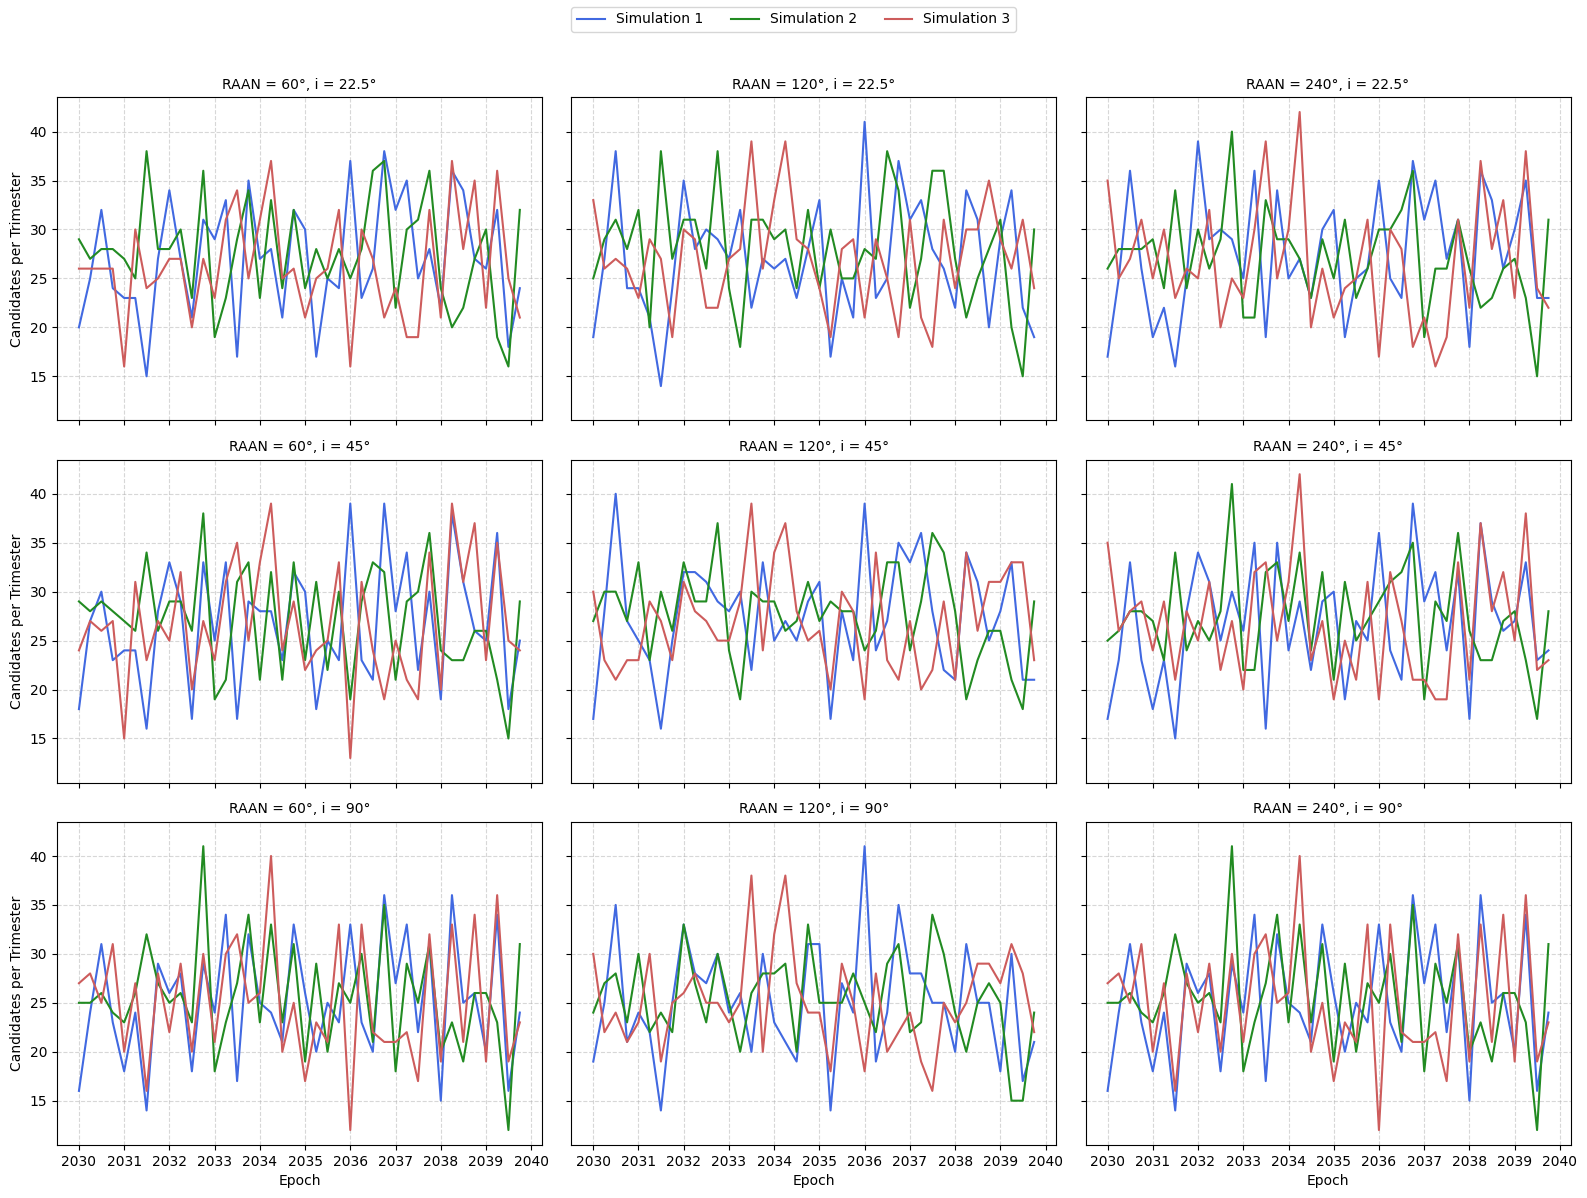

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from datetime import datetime

# Input files and labels
file_ids = ["Asteroids_6M_ID_1.txt", "Asteroids_6M_ID_2.txt", "Asteroids_6M_ID_3.txt"]
file_apps = ["Asteroids_6M_App_1.txt", "Asteroids_6M_App_2.txt", "Asteroids_6M_App_3.txt"]
labels = ["Simulation 1", "Simulation 2", "Simulation 3"]

# RAAN and Inclination configurations
RAAN_deg = [60, 120, 240]
INC_deg = [22.5, 45, 90]
RAAN_vec = np.deg2rad(RAAN_deg)
INC_vec = np.deg2rad(INC_deg)

# Output folder
output_path = "results_plane_crossing_grid"
os.makedirs(output_path, exist_ok=True)

# Collect results
summary = []

# --------- MAIN ANALYSIS LOOP ----------
for file_id, file_app, label in zip(file_ids, file_apps, labels):
    df_sorted, df_filtered = load_and_filter_data(file_id, file_app)
    
    if df_filtered.empty:
        continue

    for raan_rad, raan_d in zip(RAAN_vec, RAAN_deg):
        for inc_rad, inc_d in zip(INC_vec, INC_deg):
            df_projected = sort_asteroids(df_filtered, raan_rad, inc_rad)
            if "DateTime" not in df_projected.columns:
                continue
            df_projected["DateTime"] = pd.to_datetime(df_projected["DateTime"], errors="coerce")
            df_projected = df_projected.dropna(subset=["DateTime"])
            df_projected = df_projected[df_projected["DateTime"].dt.year <= 2039]

            n_crossings = len(df_projected)
            summary.append({
                "Scenario": label,
                "RAAN": raan_d,
                "Inc": inc_d,
                "N_cross": n_crossings
            })

            # Save histogram CSV per case
            if n_crossings > 0:
                bins = pd.date_range("2030-01-01", "2040-01-01", freq="3MS")
                hist, _ = np.histogram(df_projected["DateTime"], bins=bins)
                hist_df = pd.DataFrame({
                    "EpochStart": bins[:-1],
                    "Count": hist,
                    "Scenario": label,
                    "RAAN": raan_d,
                    "Inc": inc_d
                })
                hist_df.to_csv(f"{output_path}/hist_{label.replace(' ', '_')}_RAAN{raan_d}_INC{inc_d}.csv", index=False)

# --------- HEATMAP PLOT PER SCENARIO ----------
df_summary = pd.DataFrame(summary)
df_summary.to_csv(os.path.join(output_path, "raan_inc_plane_crossing_summary.csv"), index=False)

for scen in df_summary["Scenario"].unique():
    df_plot = df_summary[df_summary["Scenario"] == scen].pivot(index="Inc", columns="RAAN", values="N_cross")
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_plot, annot=True, fmt=".0f", cmap="crest", cbar_kws={"label": "Number of Plane Crossings"})
    plt.title(f"Plane Crossing Count — {scen}")
    plt.xlabel("RAAN [deg]")
    plt.ylabel("Inclination [deg]")
    plt.tight_layout()
    plt.savefig(f"{output_path}/crossing_heatmap_{scen.replace(' ', '_')}.pdf")
    plt.close()

# --------- TEMPORAL DISTRIBUTION GRID ----------
bins = pd.date_range("2030-01-01", "2040-01-01", freq="3MS")
colors = ["royalblue", "forestgreen", "indianred"]

fig, axs = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for i, inc in enumerate(INC_deg):
    for j, raan in enumerate(RAAN_deg):
        ax = axs[i, j]
        for scen_label, color in zip(labels, colors):
            filename = f"{output_path}/hist_{scen_label.replace(' ', '_')}_RAAN{raan}_INC{inc}.csv"
            if os.path.exists(filename):
                df = pd.read_csv(filename, parse_dates=["EpochStart"])
                ax.plot(df["EpochStart"], df["Count"], label=scen_label, color=color, linewidth=1.5)
        ax.set_title(f"RAAN = {raan}°, i = {inc}°", fontsize=10)
        if i == 2:
            ax.set_xlabel("Epoch")
        if j == 0:
            ax.set_ylabel("Candidates per Trimester")
        ax.grid(True, linestyle="--", alpha=0.5)

fig.legend(labels, loc="upper center", ncol=3, fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{output_path}/crossing_temporal_distribution_grid.pdf")

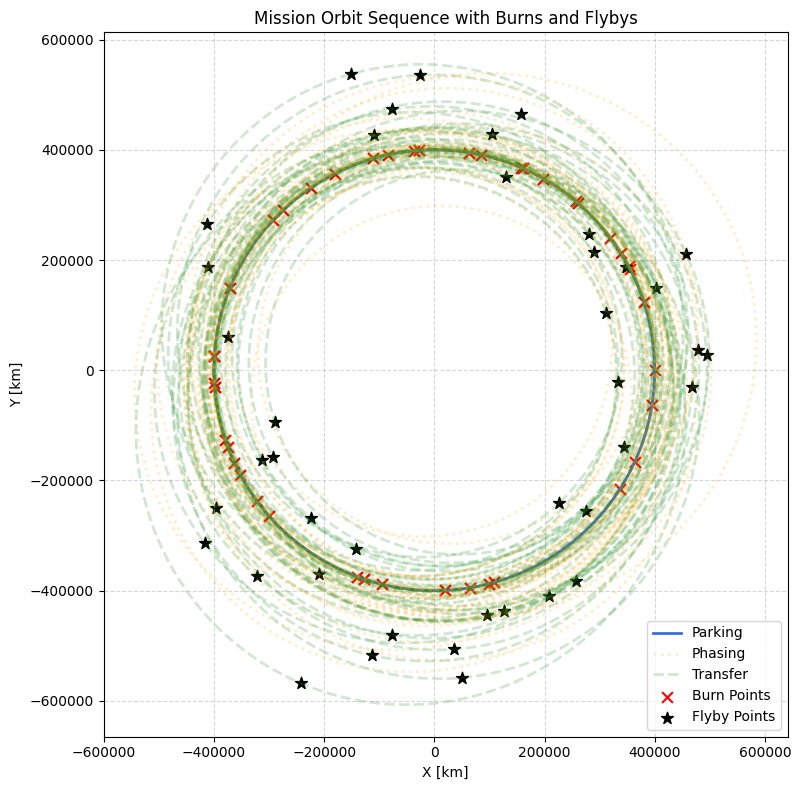

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load orbital data
df = pd.read_csv("orbits_list_3.txt", delim_whitespace=True)

# Plot setup
fig, ax = plt.subplots(figsize=(8, 8))
colors = {"parking": "royalblue", "phasing": "orange", "transfer": "forestgreen"}
labels_added = set()

# Function to draw one orbit
def plot_orbit(a, e, w, label, color, lineval, alpha_val):
    theta = np.linspace(0, 2 * np.pi, 500)
    r = a * (1 - e**2) / (1 + e * np.cos(theta))
    x = r * np.cos(theta + w)
    y = r * np.sin(theta + w)
    if label not in labels_added:
        ax.plot(x/1e3, y/1e3, color=color, label=label, linewidth=2, linestyle=lineval, alpha=alpha_val)
        labels_added.add(label)
    else:
        ax.plot(x/1e3, y/1e3, color=color, linewidth=2, linestyle=lineval, alpha=alpha_val)

# Burn and flyby markers
burn_x, burn_y = [], []
flyby_x, flyby_y = [], []

# Loop through each orbit
plotted_parking = False
for idx, row in df.reset_index(drop=True).iterrows():
    a, e, w, theta0 = row['sma'], row['ecc'], row['argperiap'], row['theta0']
    if idx == 0 and not plotted_parking:
        plot_orbit(a, e, w, 'Parking', colors['parking'], '-', 1)
        r = a * (1 - e**2) / (1 + e * np.cos(theta0))
        burn_x.append(r * np.cos(theta0 + w)/1e3)
        burn_y.append(r * np.sin(theta0 + w)/1e3)
        plotted_parking = True
    elif idx % 3 == 1:  # phasing
        plot_orbit(a, e, w, 'Phasing', colors['phasing'], ':', 0.2)
        r = a * (1 - e**2) / (1 + e * np.cos(theta0))
        burn_x.append(r * np.cos(theta0 + w)/1e3)
        burn_y.append(r * np.sin(theta0 + w)/1e3)
    elif idx % 3 == 2:  # transfer
        plot_orbit(a, e, w, 'Transfer', colors['transfer'], '--', 0.2)
        r = a * (1 - e**2) / (1 + e * np.cos(theta0))
        burn_x.append(r * np.cos(theta0 + w)/1e3)
        burn_y.append(r * np.sin(theta0 + w)/1e3)
        theta_flyby = 0 if np.isclose(theta0, np.pi) else np.pi
        r_fb = a * (1 - e**2) / (1 + e * np.cos(theta_flyby))
        flyby_x.append(r_fb * np.cos(theta_flyby + w)/1e3)
        flyby_y.append(r_fb * np.sin(theta_flyby + w)/1e3)

# Add points
ax.scatter(burn_x, burn_y, color="red", marker="x", s=60, label="Burn Points")
ax.scatter(flyby_x, flyby_y, color="black", marker="*", s=80, label="Flyby Points")

# Final display
ax.set_aspect("equal")
ax.set_xlabel("X [km]")
ax.set_ylabel("Y [km]")
ax.set_title("Mission Orbit Sequence with Burns and Flybys")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig("encounter_sequence_plot_3.pdf")
plt.show()

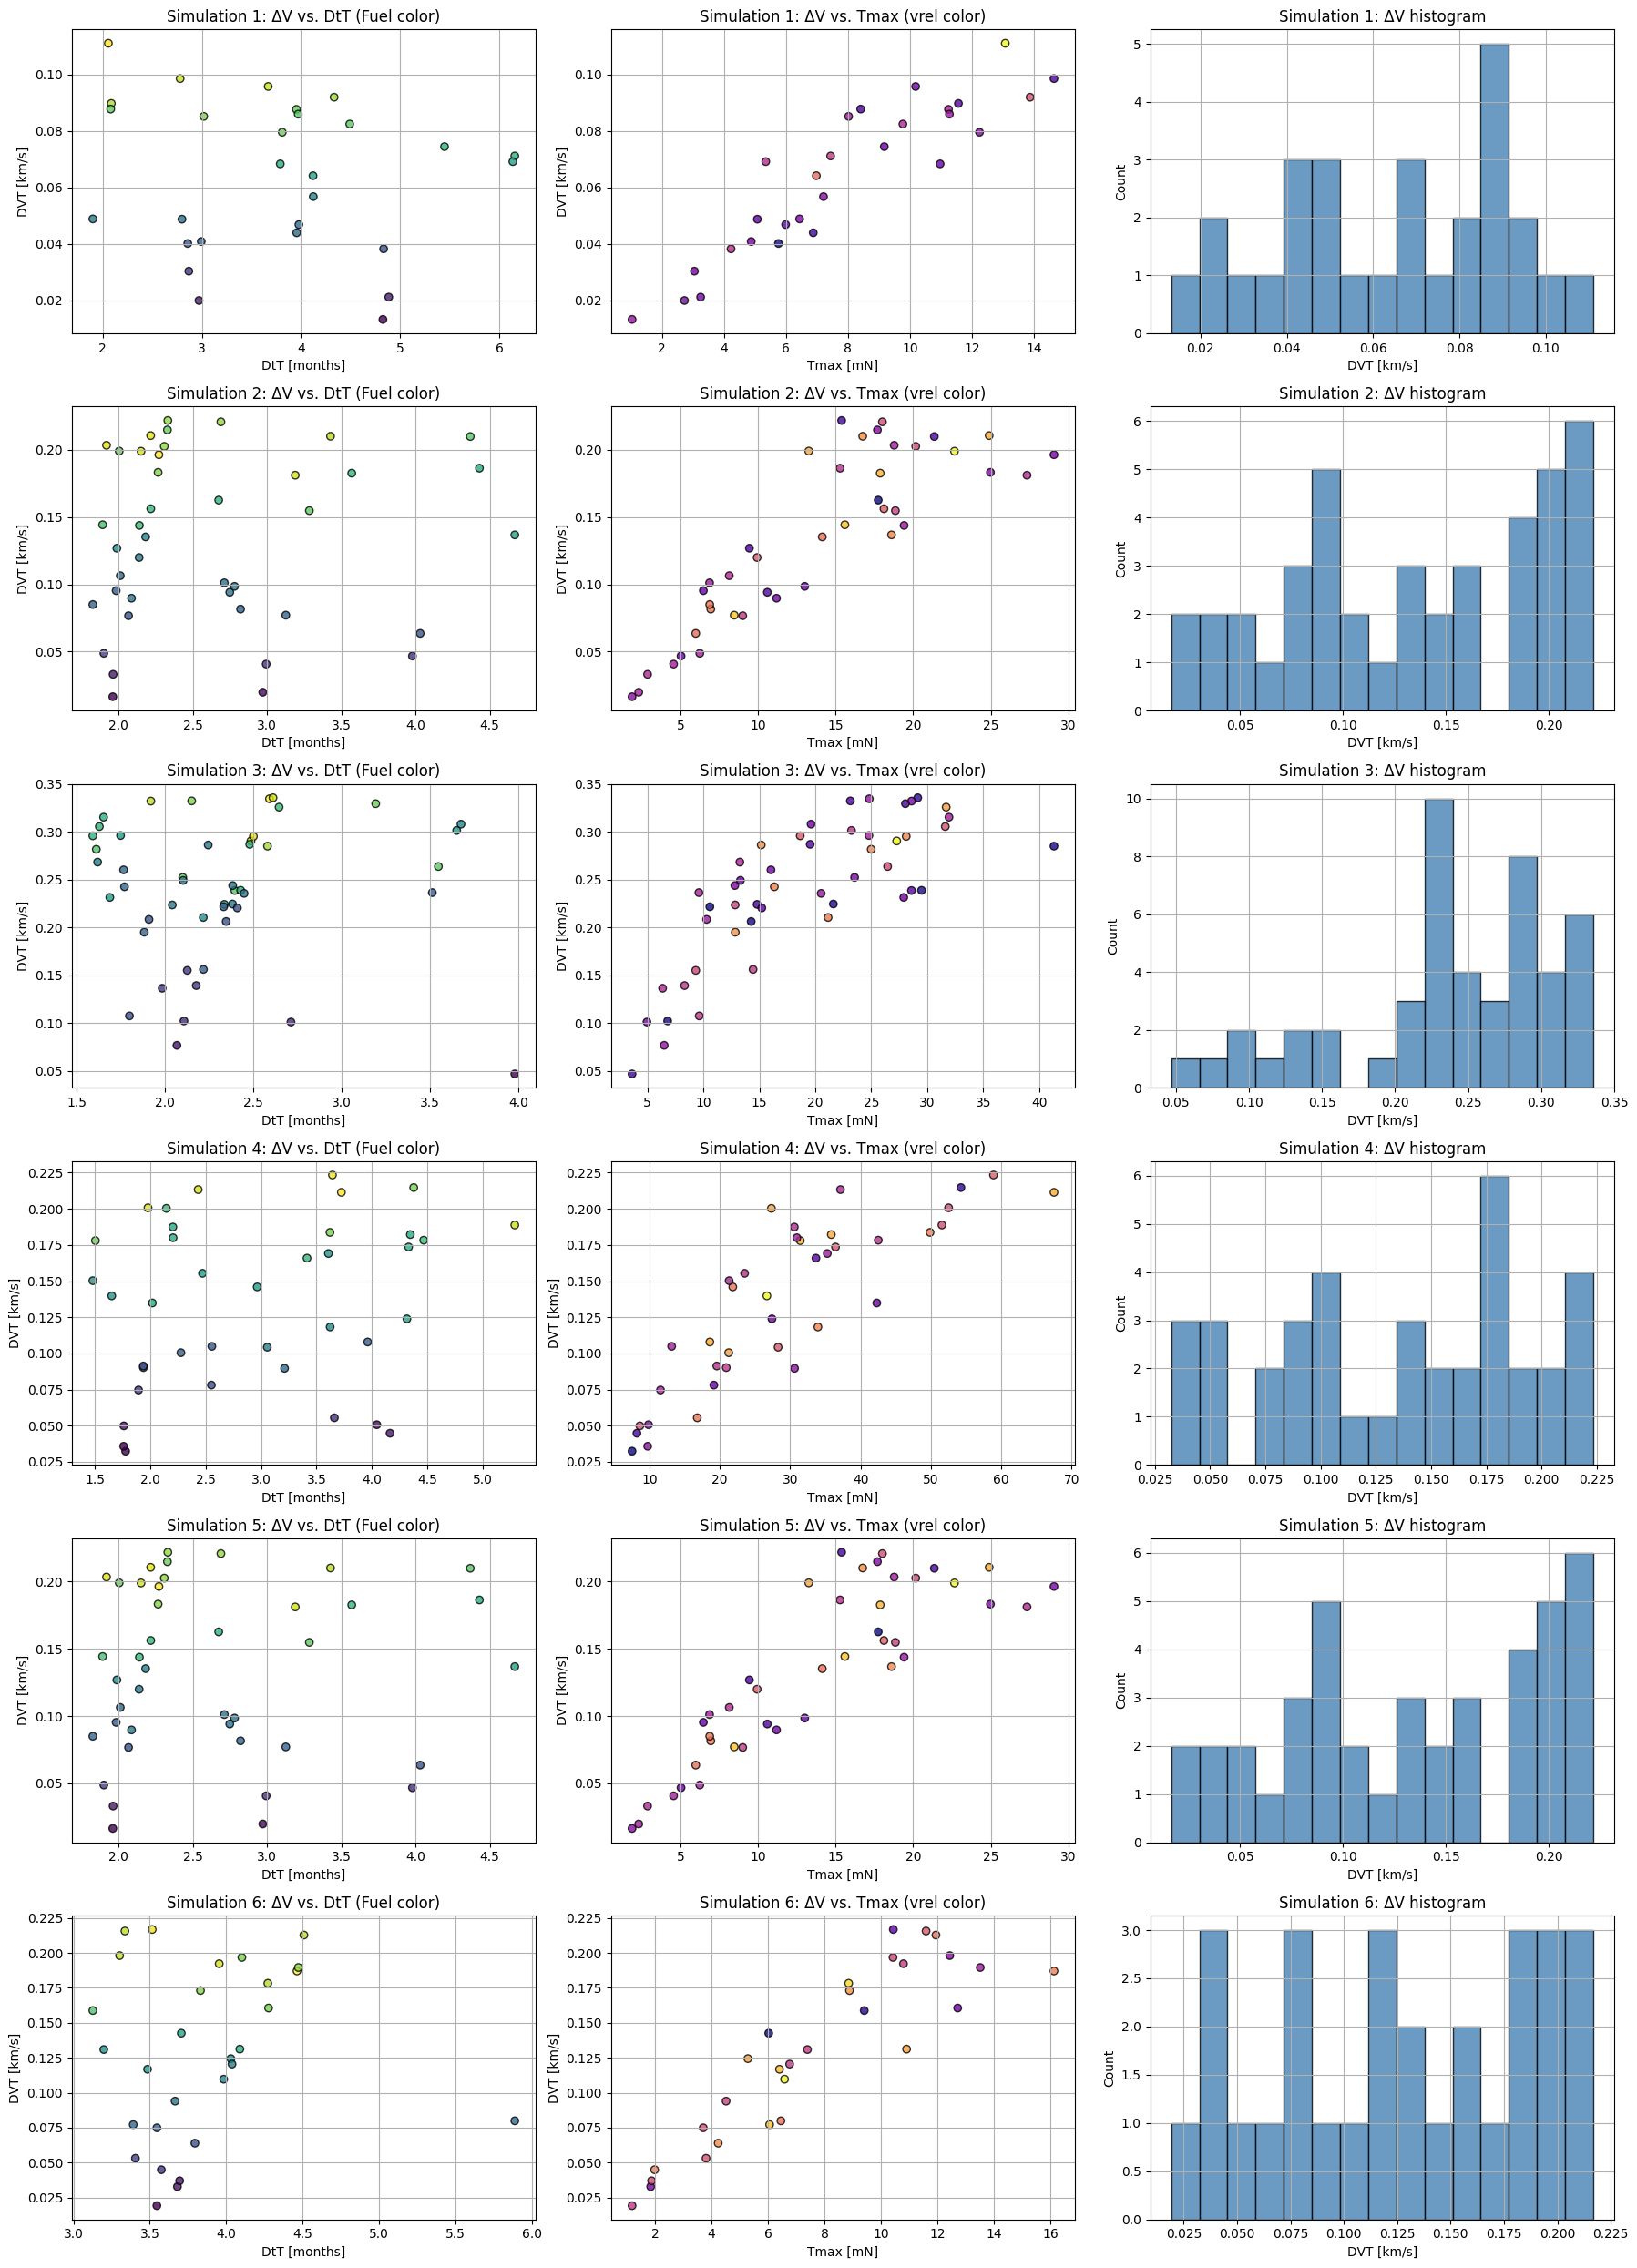

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import re

def parse_multiple_simulations(filepath):
    simulations = {}
    current_sim = None
    data = []

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('--- Scenario'):
                if current_sim is not None:
                    simulations[current_sim] = pd.DataFrame(data)
                    data = []
                current_sim = int(re.search(r'Scenario (\d+)', line).group(1))
            elif "DVT" in line:
                try:
                    dvt = float(re.search(r'DVT = ([\d.]+)', line).group(1))
                    dtt = float(re.search(r'DtT = ([\d.]+)', line).group(1))
                    tmax = float(re.search(r'Tmax = ([\d.]+)', line).group(1))
                    vrel = float(re.search(r'vrel = ([\d.]+)', line).group(1))
                    fuel = float(re.search(r'Fuel mass = ([\d.]+)', line).group(1))
                    data.append({
                        'DVT [km/s]': dvt,
                        'DtT [months]': dtt,
                        'Tmax [mN]': tmax,
                        'Fuel mass [kg]': fuel,
                        'Relative velocity [km/s]': vrel
                    })
                except AttributeError:
                    continue
        if current_sim is not None and data:
            simulations[current_sim] = pd.DataFrame(data)
    return simulations

# Load simulations
file_path = "nominal_sim_1.txt"
simulations = parse_multiple_simulations(file_path)

# Plot grid
fig, axs = plt.subplots(6, 3, figsize=(18, 25))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
titles = ['ΔV vs. DtT (Fuel color)', 'ΔV vs. Tmax (vrel color)', 'ΔV histogram']

for i in range(6):
    df = simulations.get(i + 1, pd.DataFrame())
    if df.empty:
        continue

    # ΔV vs DtT
    sc0 = axs[i, 0].scatter(df['DtT [months]'], df['DVT [km/s]'],
                            c=df['Fuel mass [kg]'], cmap='viridis', alpha=0.8, edgecolor='k')
    axs[i, 0].set_title(f'Scenario {i+1}: {titles[0]}')
    axs[i, 0].set_xlabel('DtT [months]')
    axs[i, 0].set_ylabel('DVT [km/s]')
    axs[i, 0].grid(True)

    # ΔV vs Tmax
    sc1 = axs[i, 1].scatter(df['Tmax [mN]'], df['DVT [km/s]'],
                            c=df['Relative velocity [km/s]'], cmap='plasma', alpha=0.8, edgecolor='k')
    axs[i, 1].set_title(f'Scenario {i+1}: {titles[1]}')
    axs[i, 1].set_xlabel('Tmax [mN]')
    axs[i, 1].set_ylabel('DVT [km/s]')
    axs[i, 1].grid(True)

    # ΔV histogram
    axs[i, 2].hist(df['DVT [km/s]'], bins=15, color='steelblue', edgecolor='black', alpha=0.8)
    axs[i, 2].set_title(f'Scenario {i+1}: {titles[2]}')
    axs[i, 2].set_xlabel('DVT [km/s]')
    axs[i, 2].set_ylabel('Count')
    axs[i, 2].grid(True)

plt.tight_layout()
plt.savefig("final_analysis_plot_1.pdf")
plt.show()


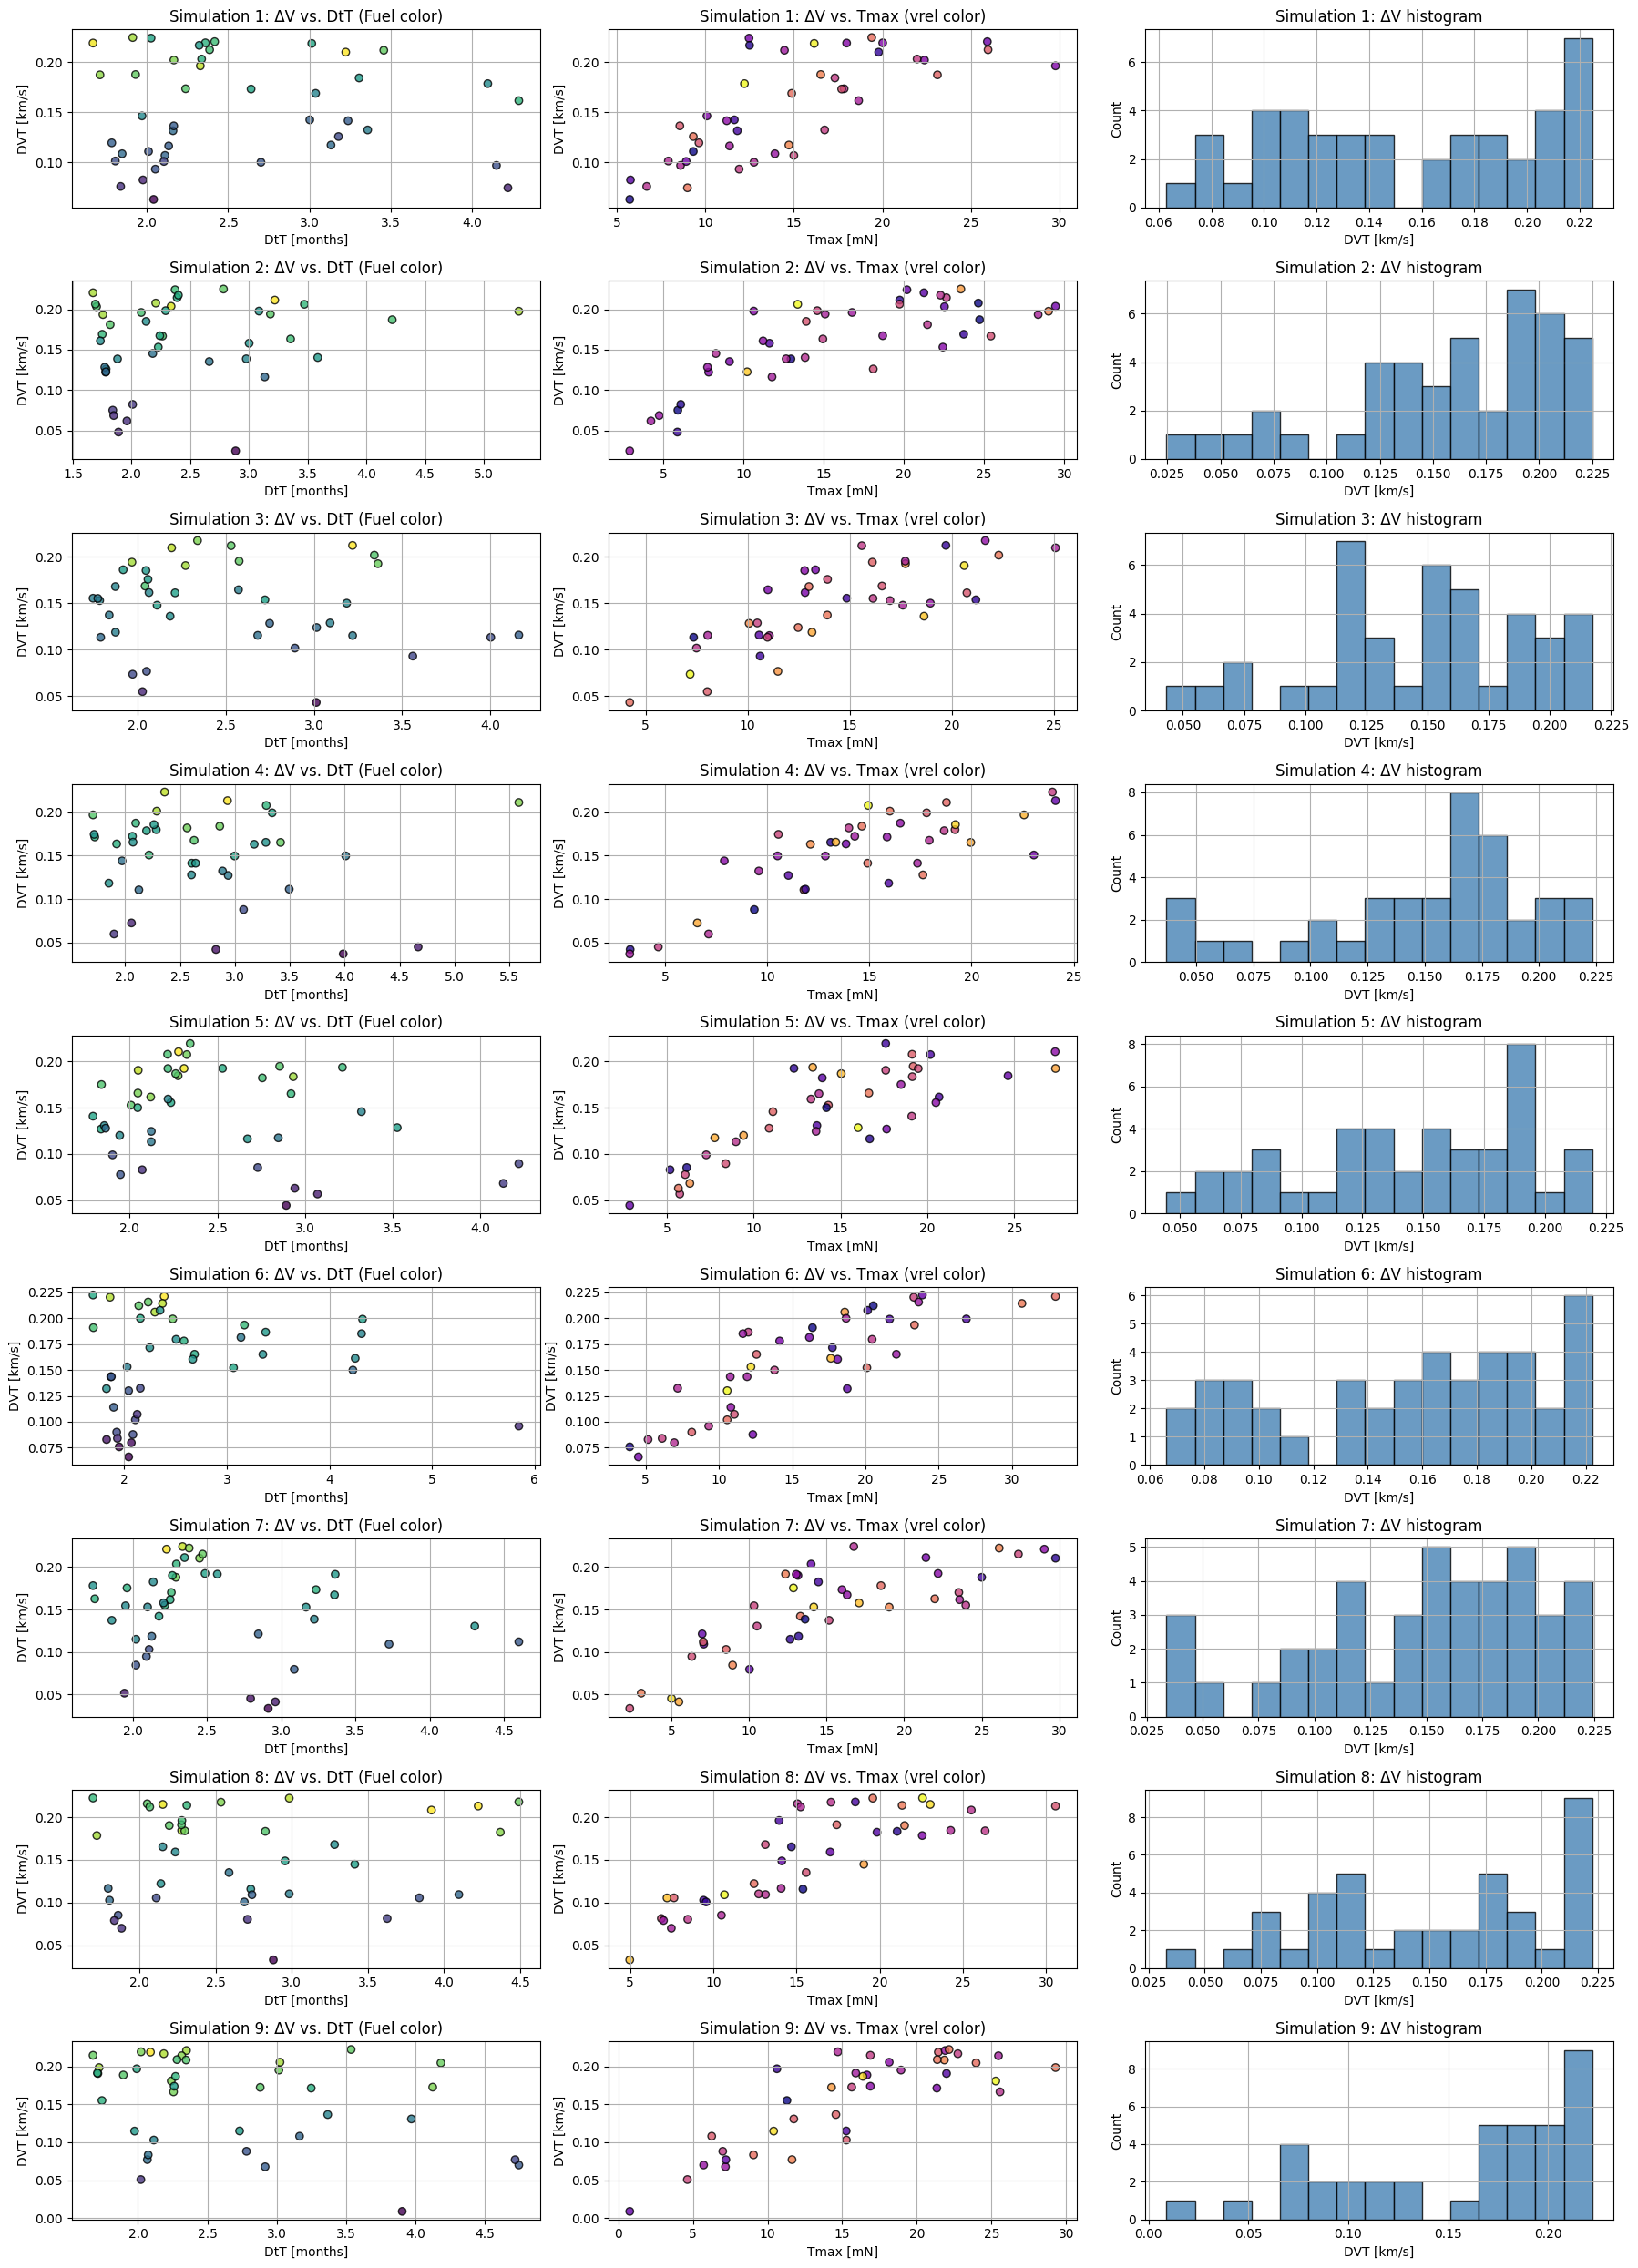

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import re

def parse_multiple_simulations(filepath):
    simulations = {}
    current_sim = None
    data = []

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('--- Scenario'):
                if current_sim is not None:
                    simulations[current_sim] = pd.DataFrame(data)
                    data = []
                current_sim = int(re.search(r'Scenario (\d+)', line).group(1))
            elif "DVT" in line:
                try:
                    dvt = float(re.search(r'DVT = ([\d.]+)', line).group(1))
                    dtt = float(re.search(r'DtT = ([\d.]+)', line).group(1))
                    tmax = float(re.search(r'Tmax = ([\d.]+)', line).group(1))
                    vrel = float(re.search(r'vrel = ([\d.]+)', line).group(1))
                    fuel = float(re.search(r'Fuel mass = ([\d.]+)', line).group(1))
                    data.append({
                        'DVT [km/s]': dvt,
                        'DtT [months]': dtt,
                        'Tmax [mN]': tmax,
                        'Fuel mass [kg]': fuel,
                        'Relative velocity [km/s]': vrel
                    })
                except AttributeError:
                    continue
        if current_sim is not None and data:
            simulations[current_sim] = pd.DataFrame(data)
    return simulations

# Load simulations
file_path = "inclined_raan_sim_3.txt"
simulations = parse_multiple_simulations(file_path)

# Plot grid
fig, axs = plt.subplots(9, 3, figsize=(18, 25))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
titles = ['ΔV vs. DtT (Fuel color)', 'ΔV vs. Tmax (vrel color)', 'ΔV histogram']

for i in range(9):
    df = simulations.get(i + 1, pd.DataFrame())
    if df.empty:
        continue

    # ΔV vs DtT
    sc0 = axs[i, 0].scatter(df['DtT [months]'], df['DVT [km/s]'],
                            c=df['Fuel mass [kg]'], cmap='viridis', alpha=0.8, edgecolor='k')
    axs[i, 0].set_title(f'Scenario {i+1}: {titles[0]}')
    axs[i, 0].set_xlabel('DtT [months]')
    axs[i, 0].set_ylabel('DVT [km/s]')
    axs[i, 0].grid(True)

    # ΔV vs Tmax
    sc1 = axs[i, 1].scatter(df['Tmax [mN]'], df['DVT [km/s]'],
                            c=df['Relative velocity [km/s]'], cmap='plasma', alpha=0.8, edgecolor='k')
    axs[i, 1].set_title(f'Scenario {i+1}: {titles[1]}')
    axs[i, 1].set_xlabel('Tmax [mN]')
    axs[i, 1].set_ylabel('DVT [km/s]')
    axs[i, 1].grid(True)

    # ΔV histogram
    axs[i, 2].hist(df['DVT [km/s]'], bins=15, color='steelblue', edgecolor='black', alpha=0.8)
    axs[i, 2].set_title(f'Scenario {i+1}: {titles[2]}')
    axs[i, 2].set_xlabel('DVT [km/s]')
    axs[i, 2].set_ylabel('Count')
    axs[i, 2].grid(True)

plt.tight_layout()
plt.savefig("inclined_analysis_plot_3.pdf")
plt.show()